In [12]:
import tellurium as te
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import platform
import roadrunner
import math
import multiprocessing as mp
from multiprocessing import Pool, cpu_count, Manager
from functools import partial
import psutil
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings
from scipy.signal import find_peaks, hilbert, savgol_filter
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')

# Fix for multiprocessing in Jupyter notebooks on macOS
# 'fork' method allows pickling functions defined in notebook cells
try:
    mp.set_start_method('fork', force=True)
    print("✅ Multiprocessing set to 'fork' mode (Jupyter-compatible)")
except RuntimeError:
    # Already set - that's fine
    pass

# Silence RoadRunner log messages completely
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

print("🧪 ChicoOscillation: Simplified Yeast Dynamics Analysis")
print("📊 Focus: Short-term dynamics with coarse-grained encoding")
print("="*60)

✅ Multiprocessing set to 'fork' mode (Jupyter-compatible)
🧪 ChicoOscillation: Simplified Yeast Dynamics Analysis
📊 Focus: Short-term dynamics with coarse-grained encoding


In [13]:
# === CPU OPTIMIZATION DETECTION ===
def detect_cpu_config():
    """Detect optimal CPU configuration for Radeon/AMD processors"""
    cpu_count_total = cpu_count()
    cpu_info = platform.processor()
    
    # Check if this is an AMD/Radeon CPU
    is_amd = any(keyword in cpu_info.lower() for keyword in ['amd', 'radeon', 'ryzen', 'epyc', 'athlon'])
    
    if is_amd:
        # AMD CPUs often benefit from using physical cores only
        try:
            physical_cores = psutil.cpu_count(logical=False)
            logical_cores = psutil.cpu_count(logical=True)
            
            # For AMD, often best to use 75-85% of physical cores for compute-heavy tasks
            optimal_workers = max(1, int(physical_cores * 0.8)) if physical_cores else max(1, int(cpu_count_total * 0.7))
            
            print(f"🔧 AMD/Radeon CPU detected: {cpu_info}")
            print(f"   Physical cores: {physical_cores}, Logical cores: {logical_cores}")
            print(f"   Optimal workers for simulation: {optimal_workers}")
            
            return optimal_workers, True
        except:
            # Fallback if psutil fails
            optimal_workers = max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD CPU detected (fallback): using {optimal_workers} workers")
            return optimal_workers, True
    else:
        # Non-AMD CPU: use standard approach
        optimal_workers = max(1, cpu_count_total - 1)
        print(f"🔧 Non-AMD CPU: using {optimal_workers} workers")
        return optimal_workers, False

OPTIMAL_WORKERS, IS_AMD_CPU = detect_cpu_config()

# Cross-platform path detection
def get_model_path():
    """Get the correct path to the SBML model file based on OS and available paths."""
    # Define possible paths
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"
    Beecroft_path = "/home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"   
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml"
    
    # Check which path exists
    if os.path.exists(linux_path):
        print("linux_path")
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    elif os.path.exists(Beecroft_path):
        print("Beecroft_path")
        return Beecroft_path
    else:
        # Fallback: try to find it relative to current directory
        possible_relative_paths = [
            "chen_model.xml",
            "Chen/chen_model.xml",
            "../Chen/chen_model.xml"
        ]
        for rel_path in possible_relative_paths:
            if os.path.exists(rel_path):
                return os.path.abspath(rel_path)
        
        # If nothing found, raise an error with helpful message
        raise FileNotFoundError(
            f"Could not find chen_model.xml in any of the expected locations:\n"
            f"  Linux: {linux_path}\n"
            f"  Mac: {mac_path}\n"
            f"Current working directory: {os.getcwd()}\n"
            f"Platform: {platform.system()}"
        )

# Load Chen 2004 budding yeast cell cycle model
model_path = get_model_path()
print(f"Loading model from: {model_path}")
rr = te.loadSBMLModel(model_path)

🔧 Non-AMD CPU: using 7 workers
Loading model from: /Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml


In [14]:
# === CHICO OSCILLATION CONFIGURATION ===
# Modified parameters for short-term dynamics analysis

# Parameter sampling configuration (same as CPUheavy)
multipliers = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]  # Discrete multipliers for parameter perturbation

# === MODIFIED SIMULATION SETTINGS ===
T = 500                           # Default simulation time (minutes) - MUCH shorter than CPUheavy!
CoarseStart = 0                  # Start time for coarse-graining window
SIMULATION_TIME = T                 # Total simulation time
SIMULATION_POINTS = 501             # Fewer points needed for shorter simulation
COARSE_BINS = 50                    # Number of bins for coarse-graining (same as CPUheavy)

# Simulation thresholds
DIVERGENCE_THRESHOLD = 250          # Reject divergent solutions
MAX_RETRY_ATTEMPTS = 20             # Maximum attempts to find valid solution in tests
SAMPLING_SIZE = 10**5               # Number of samples to analyze
PROGRESS_INTERVAL = 0.01            # Progress reporting frequency

# Phenotype tracking
N_TRACK_PHENOTYPES = 10             # Number of top/bottom phenotypes to track

# Performance optimization settings (from CPUheavy)
USE_MODEL_REUSE = True              # Reuse single model instance
BATCH_SIZE = 1000                   # Process in batches
ENABLE_FAST_REJECT = True           # Quick rejection of divergent solutions
REDUCED_PRECISION = True            # Use reduced simulation precision for speed

# === CPU PARALLELIZATION SETTINGS ===
USE_MULTIPROCESSING = True          # Enable multiprocessing
NUM_WORKERS = OPTIMAL_WORKERS       # Number of parallel workers
CHUNK_SIZE = max(100, SAMPLING_SIZE // (NUM_WORKERS * 10))  # Dynamic chunk size
USE_PROCESS_POOL = True             # Use ProcessPoolExecutor
ENABLE_MEMORY_OPTIMIZATION = True   # Enable memory optimization

# AMD/Radeon specific optimizations
if IS_AMD_CPU:
    CHUNK_SIZE = max(50, CHUNK_SIZE // 2)
    os.environ['OMP_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['MKL_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['NUMEXPR_NUM_THREADS'] = str(NUM_WORKERS)

print("✓ ChicoOscillation Configuration:")
print(f"   - Multipliers: {multipliers}")
print(f"   - Simulation time: {SIMULATION_TIME} min (SHORT-TERM FOCUS)")
print(f"   - Simulation points: {SIMULATION_POINTS}")
print(f"   - Coarse bins: {COARSE_BINS}")
print(f"   - Divergence threshold: {DIVERGENCE_THRESHOLD}")
print(f"   - Sampling size: {SAMPLING_SIZE:,}")
print(f"   - 🚀 CPU Parallelization: {USE_MULTIPROCESSING} ({NUM_WORKERS} workers)")
print(f"   - 🔧 CPU Type: {'AMD/Radeon optimized' if IS_AMD_CPU else 'Standard'}")
print(f"   - 📦 Chunk size: {CHUNK_SIZE} samples per batch")
print(f"\n🎯 KEY DIFFERENCE: No oscillation detection, just direct coarse-graining!")

✓ ChicoOscillation Configuration:
   - Multipliers: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
   - Simulation time: 500 min (SHORT-TERM FOCUS)
   - Simulation points: 501
   - Coarse bins: 50
   - Divergence threshold: 250
   - Sampling size: 100,000
   - 🚀 CPU Parallelization: True (7 workers)
   - 🔧 CPU Type: Standard
   - 📦 Chunk size: 1428 samples per batch

🎯 KEY DIFFERENCE: No oscillation detection, just direct coarse-graining!


In [15]:
# === CORE FUNCTIONS (adapted from CPUheavy) ===

def get_kinetic_parameters(rr):
    """Get list of kinetic parameters, excluding regulatory switches/flags."""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        # Exclude non-kinetic parameters (switches, flags, totals)
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

# Cache kinetic parameters globally
_kinetic_params_cache = None
_excluded_params_cache = None

def get_kinetic_parameters_cached(rr):
    """Cached version of get_kinetic_parameters for performance"""
    global _kinetic_params_cache, _excluded_params_cache
    if _kinetic_params_cache is None:
        _kinetic_params_cache, _excluded_params_cache = get_kinetic_parameters(rr)
    return _kinetic_params_cache, _excluded_params_cache

def reset_model_to_defaults(rr, default_values):
    """Quickly reset model to default parameter values"""
    for pid, default_val in default_values.items():
        try:
            rr.setValue(pid, default_val)
        except RuntimeError:
            continue

def sample_parameters_fast(rr, kinetic_params, default_values, wildtype=False):
    """Fast parameter sampling using cached parameter lists"""
    
    # Reset to defaults efficiently
    reset_model_to_defaults(rr, default_values)
    rr.resetAll()
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    # Sample only kinetic parameters using cached list
    for pid in kinetic_params:
        try:
            current = default_values[pid]  # Use cached default
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except (RuntimeError, KeyError):
            continue
    
    return sampled, sampled_values

def sample_parameters(rr, wildtype=False):
    """Standard parameter sampling (for compatibility)"""
    rr.resetAll()
    kinetic_params, excluded_params = get_kinetic_parameters(rr)
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    for pid in kinetic_params:
        try:
            current = rr.getValue(pid)
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except RuntimeError:
            continue
    
    return sampled, sampled_values

def check_divergence_fast(signal, threshold):
    """Fast divergence check on CLB2 signal"""
    if threshold is None:
        return False
    return np.any(np.abs(signal) > threshold)

print("✓ Core functions defined successfully!")

✓ Core functions defined successfully!


In [16]:
# === SIMPLIFIED SIMULATION AND ENCODING FUNCTIONS ===

def simulate_chico(rr, T=None, CoarseStart=None, npoints=None, diverge_threshold=None):
    """Simplified simulation for ChicoOscillation - simulate from 0 to CoarseStart+T"""
    
    if T is None:
        T = SIMULATION_TIME
    if CoarseStart is None:
        CoarseStart = globals().get('CoarseStart', 0)
    if npoints is None:
        npoints = SIMULATION_POINTS
    if diverge_threshold is None:
        diverge_threshold = DIVERGENCE_THRESHOLD
    
    # Set selections to minimum required
    rr.selections = ["time", "CLB2"]
    
    try:
        # Use reduced precision if enabled
        if REDUCED_PRECISION:
            old_abs_tol = rr.integrator.absolute_tolerance
            old_rel_tol = rr.integrator.relative_tolerance
            rr.integrator.absolute_tolerance = 1e-8
            rr.integrator.relative_tolerance = 1e-6
        
        # Simulate from 0 to CoarseStart+T (extended simulation)
        total_time = CoarseStart + T
        # Scale points proportionally to cover the extended time
        total_points = int(npoints * total_time / T) if T > 0 else npoints
        result = rr.simulate(0, total_time, total_points)
        
        # Restore precision if changed
        if REDUCED_PRECISION:
            rr.integrator.absolute_tolerance = old_abs_tol
            rr.integrator.relative_tolerance = old_rel_tol
            
    except RuntimeError as e:
        return None, None, None, None
    
    full_time = result[:, 0]
    full_clb2 = result[:, 1]  # CLB2 is index 1
    
    # Fast divergence check on full signal
    if ENABLE_FAST_REJECT and check_divergence_fast(full_clb2, diverge_threshold):
        return "divergent", None, None, None
    
    # Extract the window [CoarseStart, CoarseStart+T] for coarse-graining
    mask = (full_time >= CoarseStart) & (full_time <= CoarseStart + T)
    if not np.any(mask):
        # No data in the specified window
        return None, None, None, None
    
    windowed_time = full_time[mask]
    windowed_clb2 = full_clb2[mask]
    
    return windowed_time, windowed_clb2, full_time, full_clb2

def coarse_grain_direct(time, signal, nbins=None):
    """Direct coarse-graining without oscillation detection
    
    Instead of detecting periods, just coarse-grain the entire time series
    to nbins points and extract up-down encoding
    """
    if nbins is None:
        nbins = COARSE_BINS
    
    # Create evenly spaced time points for coarse-graining
    coarse_time = np.linspace(time[0], time[-1], nbins)
    
    # Interpolate signal to coarse grid
    coarse_signal = np.interp(coarse_time, time, signal)
    
    return coarse_time, coarse_signal

def up_down_encoding_chico(coarse_time, coarse_signal):
    """Create up-down encoding from coarse-grained data
    
    Calculate slopes between consecutive points and convert to binary
    """
    # Calculate slopes between consecutive points
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    
    # Convert to binary: 1 for positive slope (up), 0 for negative slope (down)
    encoding = ''.join(['1' if s > 0 else '0' for s in slopes])
    
    return encoding

def lz76_phrase_count(s: str) -> int:
    """Lempel-Ziv 76 phrase counting algorithm"""
    n = len(s)
    if n == 0:
        return 0
    i = 0
    c = 1  # at least one phrase if n>0
    k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i+k-1]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c

def CLZ(x):
    """Lempel-Ziv complexity calculation"""
    n = len(x)
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    else:
        return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))

def simulate_and_extract_chico(rr, T=None, CoarseStart=None, nbins=None, diverge_threshold=None):
    """Complete ChicoOscillation pipeline: simulate -> extract window -> coarse-grain -> encode
    
    Returns: windowed_time, windowed_clb2, coarse_data, encoding, complexity
    """
    
    # Simulate the system (returns windowed data for coarse-graining)
    windowed_time, windowed_clb2, full_time, full_clb2 = simulate_chico(rr, T, CoarseStart, None, diverge_threshold)
    
    if isinstance(windowed_time, str):  # "divergent"
        return windowed_time, None, None, None, None
    
    if windowed_time is None or windowed_clb2 is None:
        return None, None, None, None, None
    
    # Direct coarse-graining on the windowed data (no oscillation detection!)
    coarse_time, coarse_signal = coarse_grain_direct(windowed_time, windowed_clb2, nbins)
    
    # Create up-down encoding
    encoding = up_down_encoding_chico(coarse_time, coarse_signal)
    
    # Calculate complexity
    complexity = CLZ(encoding)
    
    return windowed_time, windowed_clb2, (coarse_time, coarse_signal), encoding, complexity

print("✓ ChicoOscillation simulation and encoding functions defined!")
print(f"   - Simulation time: {SIMULATION_TIME} min")
print(f"   - Coarse window: [{CoarseStart}, {CoarseStart + SIMULATION_TIME}] min")
print(f"   - Coarse bins: {COARSE_BINS}")
print(f"   - No oscillation detection - direct coarse-graining!")

# === PEAK DETECTION METHOD 3: CONSERVATIVE ===
def estimate_period_conservative(time, signal, require_peaks=4, center_on_peak=True, coarse_bins=50):
    """Conservative peak detection with strict regularity requirements"""
    time = np.asarray(time)
    signal = np.asarray(signal)

    # Apply smoothing
    if len(signal) > 21:
        signal_smooth = savgol_filter(signal, 21, 3)
    else:
        signal_smooth = signal

    # Conservative peak detection
    dynamic_prom = 0.1 * (np.max(signal_smooth) - np.min(signal_smooth))  # Higher prominence
    min_distance = len(time) // 50  # Larger minimum distance
    
    peaks, props = find_peaks(signal_smooth, 
                            prominence=dynamic_prom, 
                            distance=min_distance,
                            width=5)  # Require wider peaks

    if len(peaks) < require_peaks:
        return None, (None, None)

    # Strict regularity assessment
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    mean_period = np.mean(periods)
    
    if len(periods) < 3:  # Require more periods
        return None, (None, None)

    # Very strict thresholds
    cv_period = np.std(periods) / mean_period
    amplitudes = signal_smooth[peaks]
    cv_amplitude = np.std(amplitudes) / np.mean(amplitudes)

    if cv_period > 0.15 or cv_amplitude > 0.15:  # Much stricter
        return None, (None, None)
    
    # Additional quality checks
    # Check that peaks are well-separated in amplitude
    min_amp = np.min(amplitudes)
    max_amp = np.max(amplitudes)
    if (max_amp - min_amp) / max_amp > 0.3:  # Amplitude variation too high
        return None, (None, None)
    
    # Check period consistency
    median_period = np.median(periods)
    if np.any(np.abs(periods - median_period) / median_period > 0.2):  # Any period deviates >20%
        return None, (None, None)

    # Extract most stable cycle (middle one)
    if len(peaks) >= 4:
        mid_idx = len(peaks) // 2
        start_peak = peaks[mid_idx - 1]
        end_peak = peaks[mid_idx]
    else:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
    
    if center_on_peak:
        mid_peak = start_peak
        half_period = 0.5 * mean_period
        t_start = time[mid_peak] - half_period 
        t_end = time[mid_peak] + half_period 
        t_start = max(time[0], t_start)
        t_end = min(time[-1], t_end)
    else:
        t_start, t_end = time[start_peak], time[end_peak]

    mask = (time >= t_start) & (time <= t_end)
    cycle_time = time[mask]
    cycle_signal = signal[mask]

    if len(cycle_time) < 10:  # Require more points
        return None, (None, None)

    coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
    coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)

    return mean_period, (coarse_time, coarse_signal)

print("✓ Conservative peak detection method defined")


✓ ChicoOscillation simulation and encoding functions defined!
   - Simulation time: 500 min
   - Coarse window: [0, 500] min
   - Coarse bins: 50
   - No oscillation detection - direct coarse-graining!
✓ Conservative peak detection method defined


In [17]:
# === CONSERVATIVE PEAK DETECTION FOR OSCILLATION VALIDATION ===
CONSERVATIVE=False
if CONSERVATIVE:
    def estimate_period_conservative(time, signal, require_peaks=4, center_on_peak=True, coarse_bins=50):
        """
        Conservative peak detection with strict regularity requirements.
        Only accepts clear, regular oscillations with high quality standards.
        """
        time = np.asarray(time)
        signal = np.asarray(signal)

        # Apply smoothing
        if len(signal) > 21:
            signal_smooth = savgol_filter(signal, 21, 3)
        else:
            signal_smooth = signal

        # Conservative peak detection
        dynamic_prom = 0.1 * (np.max(signal_smooth) - np.min(signal_smooth))  # Higher prominence
        min_distance = len(time) // 50  # Larger minimum distance
        
        peaks, props = find_peaks(signal_smooth, 
                                prominence=dynamic_prom, 
                                distance=min_distance,
                                width=5)  # Require wider peaks

        if len(peaks) < require_peaks:
            return None, (None, None)

        # Check that signal goes below 0.05 between consecutive peaks
        for i in range(len(peaks) - 1):
            start_idx = peaks[i]
            end_idx = peaks[i + 1]
            between_peaks = signal[start_idx:end_idx]  # Use original signal, not smoothed
            if np.min(between_peaks) >= 0.05:
                return None, (None, None)

        # Strict regularity assessment
        peak_times = time[peaks]
        periods = np.diff(peak_times)
        mean_period = np.mean(periods)
        
        if len(periods) < 3:  # Require more periods
            return None, (None, None)

        # Very strict thresholds
        cv_period = np.std(periods) / mean_period
        amplitudes = signal_smooth[peaks]
        cv_amplitude = np.std(amplitudes) / np.mean(amplitudes)

        if cv_period > 0.15 or cv_amplitude > 0.15:  # Much stricter
            return None, (None, None)
        
        # Additional quality checks
        # Check that peaks are well-separated in amplitude
        min_amp = np.min(amplitudes)
        max_amp = np.max(amplitudes)
        if (max_amp - min_amp) / max_amp > 0.3:  # Amplitude variation too high
            return None, (None, None)
        
        # Check period consistency
        median_period = np.median(periods)
        if np.any(np.abs(periods - median_period) / median_period > 0.2):  # Any period deviates >20%
            return None, (None, None)

        # Extract most stable cycle (middle one)
        if len(peaks) >= 4:
            mid_idx = len(peaks) // 2
            start_peak = peaks[mid_idx - 1]
            end_peak = peaks[mid_idx]
        else:
            start_peak = peaks[-2]
            end_peak = peaks[-1]
        
        if center_on_peak:
            mid_peak = start_peak
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            t_start, t_end = time[start_peak], time[end_peak]

        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]

        if len(cycle_time) < 10:  # Require more points
            return None, (None, None)

        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)

        return mean_period, (coarse_time, coarse_signal)



    print("✓ Conservative peak detection functions defined!")
    print("   - Strict regularity requirements (CV < 0.15)")
    print("   - Requires 4+ peaks with consistent amplitude and period")
    print("   - Signal must drop below 0.05 between peaks")
    print("   - Only accepts high-quality oscillations")

else:
    def estimate_period_conservative(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
        """Original peak detection method from the base code"""
        time = np.asarray(time)
        signal = np.asarray(signal)

        # Basic peak detection
        dynamic_prom = 0.05 * (np.max(signal) - np.min(signal))
        peaks, props = find_peaks(signal, prominence=dynamic_prom, distance=len(time)//100)

        if len(peaks) < require_peaks:
            return None, (None, None)

        # Check that signal goes below 0.05 between consecutive peaks
        for i in range(len(peaks) - 1):
            start_idx = peaks[i]
            end_idx = peaks[i + 1]
            between_peaks = signal[start_idx:end_idx]
            if np.min(between_peaks) >= 0.05:
                return None, (None, None)

        # Compute periods
        peak_times = time[peaks]
        periods = np.diff(peak_times)
        mean_period = np.mean(periods)
        
        if len(periods) < 2:
            return None, (None, None)

        # Assess regularity
        cv_period = np.std(periods) / mean_period
        amplitudes = signal[peaks]
        cv_amplitude = np.std(amplitudes) / np.mean(amplitudes)

        if cv_period > 0.3 or cv_amplitude > 0.3:
            return None, (None, None)

        # Extract cycle
        if center_on_peak:
            mid_peak = peaks[-2]
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            start_peak = peaks[-2]
            end_peak = peaks[-1]
            t_start, t_end = time[start_peak], time[end_peak]

        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]

        if len(cycle_time) < 5:
            return None, (None, None)

        # Resample to coarse grid
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)

        return mean_period, (coarse_time, coarse_signal)

    print("✓ Original peak detection method defined")
    print("   - Signal must drop below 0.05 between peaks")

def test_oscillation_conservative(time_data, clb2_data):
    """Test if the trajectory passes conservative oscillation criteria"""
    if time_data is None or clb2_data is None:
        return False
    if isinstance(time_data, str):  # "divergent"
        return False
    
    try:
        period, cycle_data = estimate_period_conservative(time_data, clb2_data)
        if period is not None and cycle_data[0] is not None:
            return True
        return False
    except:
        return False

✓ Original peak detection method defined
   - Signal must drop below 0.05 between peaks


In [18]:
# === TEST CHICO OSCILLATION APPROACH ===
print("🧪 Testing ChicoOscillation approach...")
print("="*50)

# Create plots directory
os.makedirs('plots', exist_ok=True)

# === GENERATE WILDTYPE REFERENCE DATA ===
print("\n1. Generating wildtype reference data:")
rr_wt = te.loadSBMLModel(model_path)
sampled_wt, values_wt = sample_parameters(rr_wt, wildtype=True)
time_wt, clb2_wt, coarse_data_wt, encoding_wt, complexity_wt = simulate_and_extract_chico(rr_wt, T=T)

# Store wildtype data globally for visualization
WILDTYPE_ENCODING = None
WILDTYPE_COMPLEXITY = None
WILDTYPE_TRAJECTORY_DATA = None

if time_wt is not None and not isinstance(time_wt, str):
    coarse_time_wt, coarse_signal_wt = coarse_data_wt
    
    # Store wildtype reference data
    WILDTYPE_ENCODING = encoding_wt
    WILDTYPE_COMPLEXITY = complexity_wt
    WILDTYPE_TRAJECTORY_DATA = {
        'time': time_wt,
        'clb2': clb2_wt,
        'coarse_time': coarse_time_wt,
        'coarse_signal': coarse_signal_wt,
        'encoding': encoding_wt,
        'complexity': complexity_wt
    }
    
    print(f"   ✅ Wildtype simulation successful")
    print(f"   📊 Time range: {time_wt[0]:.1f} - {time_wt[-1]:.1f} min")
    print(f"   📊 CLB2 range: {np.min(clb2_wt):.3f} - {np.max(clb2_wt):.3f}")
    print(f"   📊 Coarse-grained to {len(coarse_time_wt)} points")
    print(f"   📊 Encoding length: {len(encoding_wt)} bits")
    print(f"   📊 Encoding: {encoding_wt[:30]}...")
    print(f"   📊 Complexity: {complexity_wt:.3f}")
    print(f"   📊 Wildtype data stored for visualization reference")
else:
    print(f"   ❌ Wildtype simulation failed: {time_wt}")

# === GENERATE RANDOMIZED EXAMPLE ===
print("\n2. Testing with randomized parameters:")
rr_rand = te.loadSBMLModel(model_path)
sampled_rand, values_rand = sample_parameters(rr_rand, wildtype=False)
time_rand, clb2_rand, coarse_data_rand, encoding_rand, complexity_rand = simulate_and_extract_chico(rr_rand, T=T)

# Store randomized example for visualization
RANDOMIZED_TRAJECTORY_DATA = None

if time_rand is not None and not isinstance(time_rand, str):
    coarse_time_rand, coarse_signal_rand = coarse_data_rand
    
    # Store randomized example data
    RANDOMIZED_TRAJECTORY_DATA = {
        'time': time_rand,
        'clb2': clb2_rand,
        'coarse_time': coarse_time_rand,
        'coarse_signal': coarse_signal_rand,
        'encoding': encoding_rand,
        'complexity': complexity_rand
    }
    
    print(f"   ✅ Randomized simulation successful")
    print(f"   📊 Time range: {time_rand[0]:.1f} - {time_rand[-1]:.1f} min")
    print(f"   📊 CLB2 range: {np.min(clb2_rand):.3f} - {np.max(clb2_rand):.3f}")
    print(f"   📊 Coarse-grained to {len(coarse_time_rand)} points")
    print(f"   📊 Encoding length: {len(encoding_rand)} bits")
    print(f"   📊 Encoding: {encoding_rand[:30]}...")
    print(f"   📊 Complexity: {complexity_rand:.3f}")
    print(f"   📊 Sample parameters: {values_rand[:5]}...")
    print(f"   📊 Randomized data stored for visualization reference")
else:
    print(f"   ❌ Randomized simulation failed: {time_rand}")



🧪 Testing ChicoOscillation approach...

1. Generating wildtype reference data:
   ✅ Wildtype simulation successful
   📊 Time range: 0.0 - 500.0 min
   📊 CLB2 range: 0.000 - 1.432
   📊 Coarse-grained to 50 points
   📊 Encoding length: 49 bits
   📊 Encoding: 011111111001111111100111111100...
   📊 Complexity: 30.881
   📊 Wildtype data stored for visualization reference

2. Testing with randomized parameters:
   ✅ Randomized simulation successful
   📊 Time range: 0.0 - 500.0 min
   📊 CLB2 range: 0.000 - 0.201
   📊 Coarse-grained to 50 points
   📊 Encoding length: 49 bits
   📊 Encoding: 000000000001111111111111111111...
   📊 Complexity: 16.844
   📊 Sample parameters: [2.0, 2.0, 0.25, 1.5, 1.25]...
   📊 Randomized data stored for visualization reference


📈 Visualizing ChicoOscillation results...


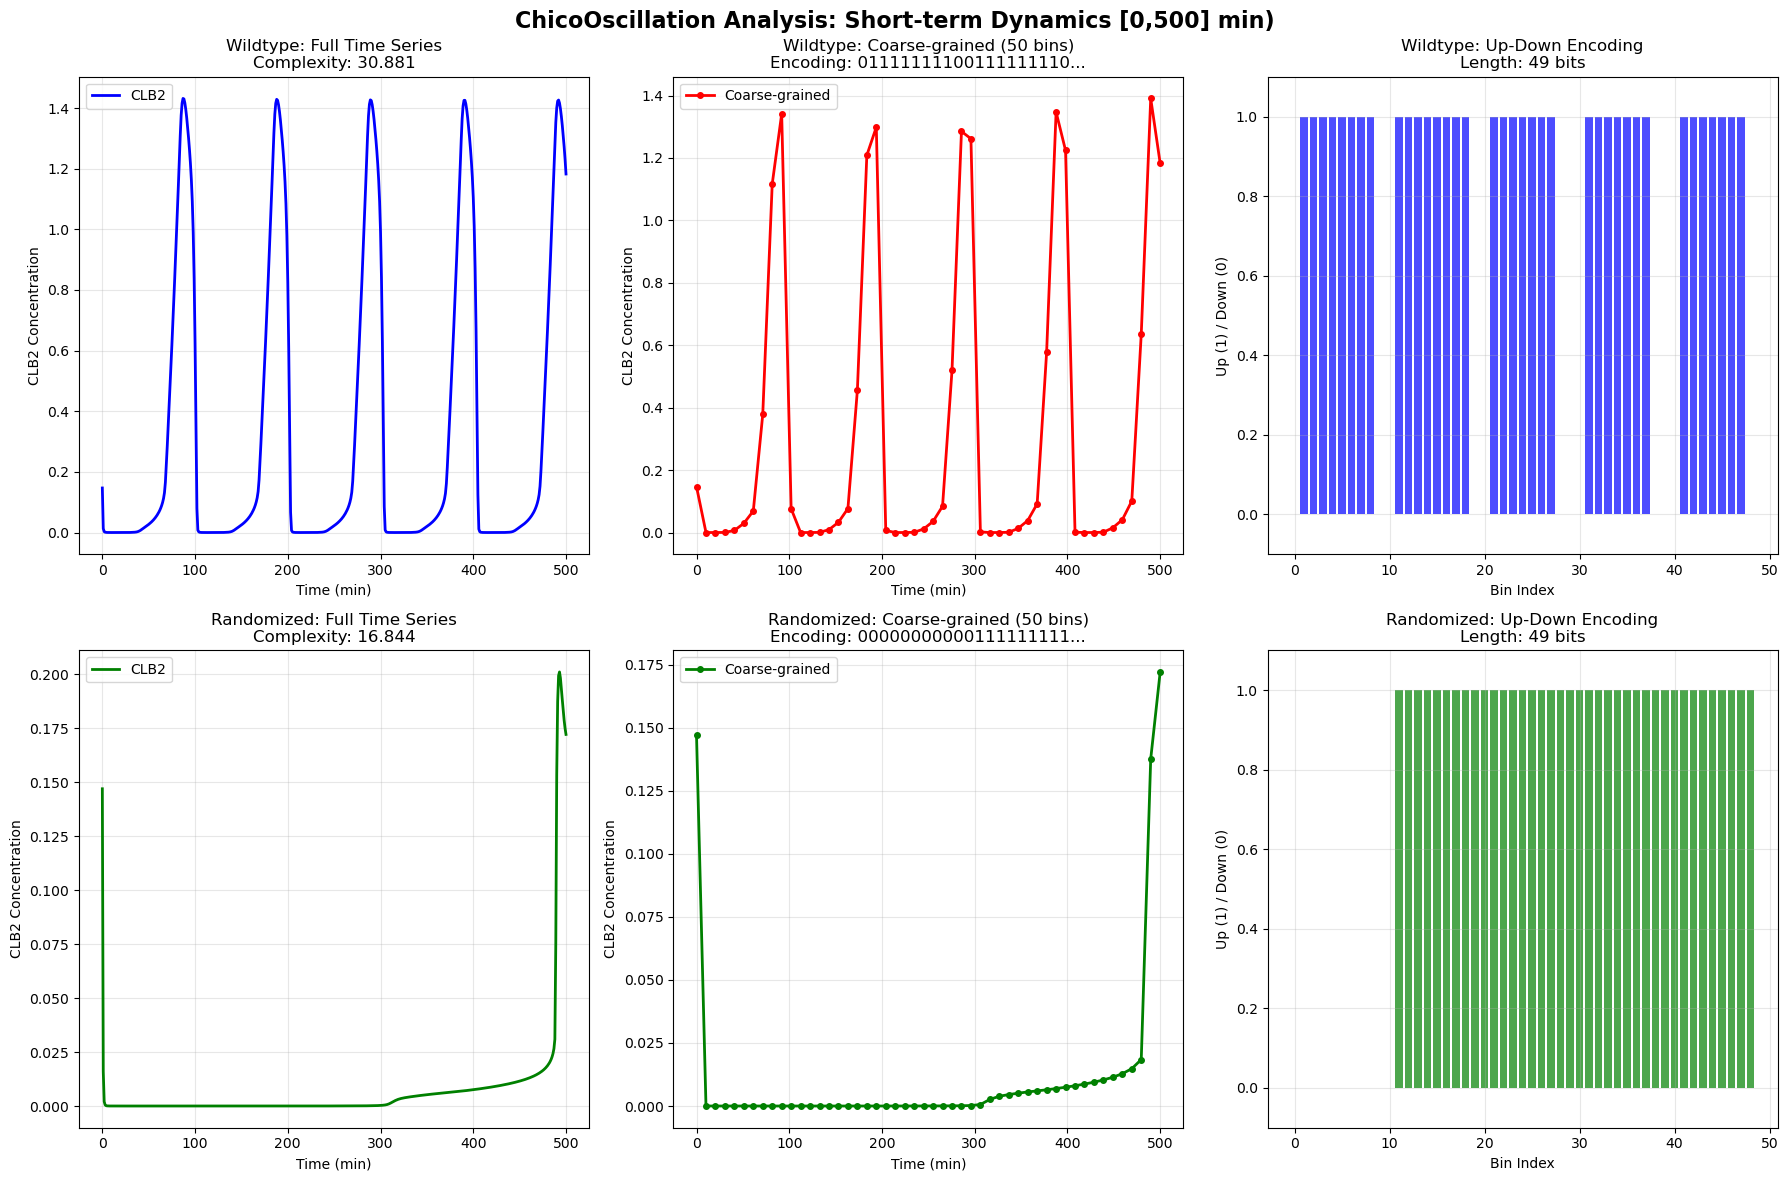


💾 Visualization saved: plots/chico_oscillation_overview.png

📊 CHICO vs CPUHEAVY COMPARISON:
   ChicoOscillation (T=500):
   ├─ Simulation time: 500 min (vs 1000 min in CPUheavy)
   ├─ No oscillation detection required
   ├─ Direct coarse-graining to 50 bins
   ├─ Encoding length: 49 bits
   └─ Focus: Short-term pattern dynamics

   CPUheavy (T=1000):
   ├─ Long simulation for full oscillations
   ├─ Peak detection and period extraction
   ├─ Cycle-based coarse-graining
   └─ Focus: Complete oscillatory behavior


In [19]:
# === VISUALIZATION OF CHICO APPROACH ===
print("📈 Visualizing ChicoOscillation results...")

# Create comprehensive plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'ChicoOscillation Analysis: Short-term Dynamics [{CoarseStart},{CoarseStart+T}] min)', fontsize=16, fontweight='bold')

# Plot 1: Wildtype full time series
if time_wt is not None and not isinstance(time_wt, str):
    axes[0, 0].plot(time_wt, clb2_wt, 'b-', linewidth=2, label='CLB2')
    axes[0, 0].set_title(f'Wildtype: Full Time Series\nComplexity: {complexity_wt:.3f}')
    axes[0, 0].set_xlabel('Time (min)')
    axes[0, 0].set_ylabel('CLB2 Concentration')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

# Plot 2: Wildtype coarse-grained
if time_wt is not None and not isinstance(time_wt, str):
    axes[0, 1].plot(coarse_time_wt, coarse_signal_wt, 'ro-', markersize=4, linewidth=2, label='Coarse-grained')
    axes[0, 1].set_title(f'Wildtype: Coarse-grained ({COARSE_BINS} bins)\nEncoding: {encoding_wt[:20]}...')
    axes[0, 1].set_xlabel('Time (min)')
    axes[0, 1].set_ylabel('CLB2 Concentration')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

# Plot 3: Wildtype encoding visualization
if time_wt is not None and not isinstance(time_wt, str):
    encoding_array = np.array([int(bit) for bit in encoding_wt])
    axes[0, 2].bar(range(len(encoding_array)), encoding_array, alpha=0.7, color='blue')
    axes[0, 2].set_title(f'Wildtype: Up-Down Encoding\nLength: {len(encoding_wt)} bits')
    axes[0, 2].set_xlabel('Bin Index')
    axes[0, 2].set_ylabel('Up (1) / Down (0)')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_ylim(-0.1, 1.1)

# Plot 4: Randomized full time series
if time_rand is not None and not isinstance(time_rand, str):
    axes[1, 0].plot(time_rand, clb2_rand, 'g-', linewidth=2, label='CLB2')
    axes[1, 0].set_title(f'Randomized: Full Time Series\nComplexity: {complexity_rand:.3f}')
    axes[1, 0].set_xlabel('Time (min)')
    axes[1, 0].set_ylabel('CLB2 Concentration')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

# Plot 5: Randomized coarse-grained
if time_rand is not None and not isinstance(time_rand, str):
    axes[1, 1].plot(coarse_time_rand, coarse_signal_rand, 'go-', markersize=4, linewidth=2, label='Coarse-grained')
    axes[1, 1].set_title(f'Randomized: Coarse-grained ({COARSE_BINS} bins)\nEncoding: {encoding_rand[:20]}...')
    axes[1, 1].set_xlabel('Time (min)')
    axes[1, 1].set_ylabel('CLB2 Concentration')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

# Plot 6: Randomized encoding visualization
if time_rand is not None and not isinstance(time_rand, str):
    encoding_array_rand = np.array([int(bit) for bit in encoding_rand])
    axes[1, 2].bar(range(len(encoding_array_rand)), encoding_array_rand, alpha=0.7, color='green')
    axes[1, 2].set_title(f'Randomized: Up-Down Encoding\nLength: {len(encoding_rand)} bits')
    axes[1, 2].set_xlabel('Bin Index')
    axes[1, 2].set_ylabel('Up (1) / Down (0)')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('plots/chico_oscillation_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved: plots/chico_oscillation_overview.png")

# Summary comparison
print(f"\n📊 CHICO vs CPUHEAVY COMPARISON:")
print(f"   ChicoOscillation (T={T}):")
print(f"   ├─ Simulation time: {T} min (vs 1000 min in CPUheavy)")
print(f"   ├─ No oscillation detection required")
print(f"   ├─ Direct coarse-graining to {COARSE_BINS} bins")
print(f"   ├─ Encoding length: {len(encoding_wt) if encoding_wt else 'N/A'} bits")
print(f"   └─ Focus: Short-term pattern dynamics")
print(f"")
print(f"   CPUheavy (T=1000):")
print(f"   ├─ Long simulation for full oscillations")
print(f"   ├─ Peak detection and period extraction")
print(f"   ├─ Cycle-based coarse-graining")
print(f"   └─ Focus: Complete oscillatory behavior")

In [20]:
# === BATCH PROCESSING WITH PARALLELIZATION ===
# (Adapted from CPUheavy with ChicoOscillation modifications)

def process_batch_chico_worker(args):
    """Optimized batch worker for ChicoOscillation analysis with conservative oscillation testing"""
    batch_start, batch_size, model_path, T_val = args
    
    # Initialize batch results
    batch_results = {
        'encodings': [],
        'complexities': [],
        'divergent_count': 0,
        'success_count': 0,
        'tracked_data': [],
        'oscillation_pass_count': 0,  # NEW: Count of oscillations passing conservative test
        'oscillation_examples': []     # NEW: Store first 100 passing oscillations
    }
    
    try:
        # Load model once per worker
        rr = te.loadSBMLModel(model_path)
        kinetic_params, _ = get_kinetic_parameters_cached(rr)
        
        # Get default parameter values for fast reset
        default_values = {pid: rr.getValue(pid) for pid in kinetic_params}
        
        # Process batch
        for i in range(batch_size):
            # Sample parameters
            sampled_params, sampled_values = sample_parameters_fast(
                rr, kinetic_params, default_values, wildtype=False
            )
            
            # Simulate and extract phenotype
            time_data, clb2_data, coarse_data, encoding, complexity = simulate_and_extract_chico(
                rr, T=T_val, CoarseStart=CoarseStart
            )
            
            # Classify result
            if isinstance(time_data, str) and time_data == "divergent":
                batch_results['divergent_count'] += 1
            elif time_data is None or encoding is None:
                batch_results['divergent_count'] += 1  # Count as divergent
            else:
                # Success: store results
                batch_results['success_count'] += 1
                batch_results['encodings'].append(encoding)
                batch_results['complexities'].append(complexity)
                
                # NEW: Test if passes conservative oscillation detection
                if test_oscillation_conservative(time_data, clb2_data):
                    batch_results['oscillation_pass_count'] += 1
                    
                    # Save first 100 passing oscillations with full data
                    if len(batch_results['oscillation_examples']) < 100:
                        batch_results['oscillation_examples'].append({
                            'time_data': time_data.copy(),
                            'clb2_data': clb2_data.copy(),
                            'coarse_data': (coarse_data[0].copy(), coarse_data[1].copy()) if coarse_data[0] is not None else (None, None),
                            'encoding': encoding,
                            'complexity': complexity,
                            'genotype': sampled_values.copy()
                        })
                
                # Store minimal data for tracking
                if len(batch_results['tracked_data']) < N_TRACK_PHENOTYPES * 3:
                    phenotype_data = {
                        'time_data': time_data,
                        'clb2_data': clb2_data,
                        'coarse_data': coarse_data,
                        'encoding': encoding,
                        'complexity': complexity
                    }
                    lightweight_genotype = {f'param_{j}': val for j, val in enumerate(sampled_values)}
                    batch_results['tracked_data'].append((encoding, lightweight_genotype, phenotype_data))
        
        return batch_results
        
    except Exception as e:
        print(f"Worker error: {e}")
        return batch_results

def merge_batch_results_chico(all_results):
    """Merge results from all ChicoOscillation worker batches"""
    merged = {
        'encodings': [],
        'complexities': [],
        'divergent_count': 0,
        'success_count': 0,
        'tracked_data': [],
        'oscillation_pass_count': 0,  # NEW
        'oscillation_examples': []     # NEW
    }
    
    for batch_result in all_results:
        merged['encodings'].extend(batch_result['encodings'])
        merged['complexities'].extend(batch_result['complexities'])
        merged['divergent_count'] += batch_result['divergent_count']
        merged['success_count'] += batch_result['success_count']
        merged['tracked_data'].extend(batch_result['tracked_data'])
        merged['oscillation_pass_count'] += batch_result.get('oscillation_pass_count', 0)  # NEW
        
        # Merge oscillation examples (keep only first 100 total)
        if len(merged['oscillation_examples']) < 100:
            examples_to_add = batch_result.get('oscillation_examples', [])
            space_left = 100 - len(merged['oscillation_examples'])
            merged['oscillation_examples'].extend(examples_to_add[:space_left])
    
    return merged

print("✓ ChicoOscillation batch processing functions defined!")
print(f"   - Optimized for T={T} min simulations")
print(f"   - Parallel processing with {NUM_WORKERS} workers")
print(f"   - Batch size: {BATCH_SIZE}")

✓ ChicoOscillation batch processing functions defined!
   - Optimized for T=500 min simulations
   - Parallel processing with 7 workers
   - Batch size: 1000


🚀 RUNNING MULTI-WINDOW COMPLEXITY ANALYSIS
📊 Analyzing 2 different time windows
📊 100,000 samples per window
🔧 Using 7 parallel workers
🔬 Testing oscillations with CONSERVATIVE peak detection

🔄 Processing window 1/2: [0, 250] min
   Progress: 20/100 batches (20.0%)
   Progress: 40/100 batches (40.0%)
   Progress: 60/100 batches (60.0%)
   Progress: 80/100 batches (80.0%)
   Progress: 100/100 batches (100.0%)
   ✅ Completed: 89,554 successful samples in 548.0s (163.4 samples/s)
   🔬 Oscillation test: 1,279 passed conservative detection (1.43%)
   💾 Saved 100 oscillation examples for visualization

🔄 Processing window 2/2: [0, 500] min
   Progress: 20/100 batches (20.0%)
   Progress: 40/100 batches (40.0%)
   Progress: 60/100 batches (60.0%)
   Progress: 80/100 batches (80.0%)
   Progress: 100/100 batches (100.0%)
   ✅ Completed: 75,080 successful samples in 811.3s (92.5 samples/s)
   🔬 Oscillation test: 6,326 passed conservative detection (8.43%)
   💾 Saved 100 oscillation examples for

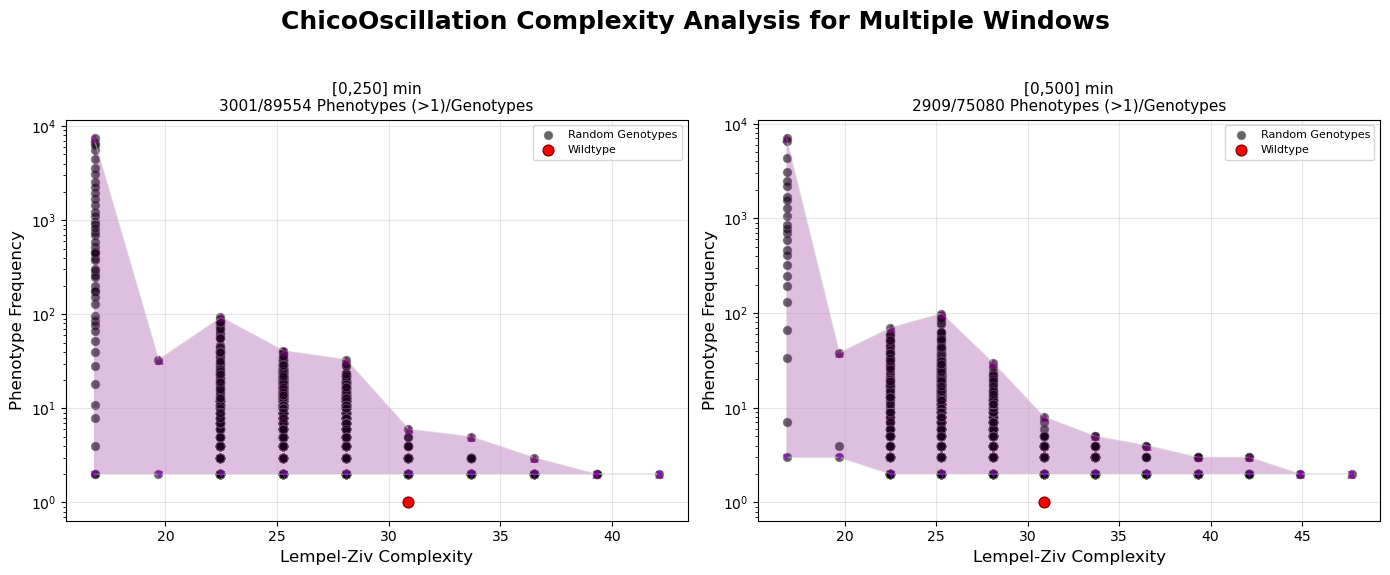


✅ MULTI-WINDOW ANALYSIS COMPLETED!
💾 Plot saved: plots/chico_multi_window_analysis.png

✅ MULTI-WINDOW ANALYSIS COMPLETED!
💾 Plot saved: plots/chico_multi_window_analysis.png

🔄 Creating frequency rank plots for all windows...
   (Reusing data from complexity analysis - no recalculation needed)


In [ ]:
# === MULTI-WINDOW COMPLEXITY PHENOTYPE ANALYSIS WITH PURPLE HULL SUBPLOTS ===
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import time

# Define window ranges
windows = [(0, 250), (0, 500)]
SAMPLING_SIZE_WINDOWS = 10**5  # Number of samples per window
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

# Storage for reusing data in rank plots
windows_data_storage = []
oscillation_pass_counts = []  # NEW: Track oscillation pass counts

print("🚀 RUNNING MULTI-WINDOW COMPLEXITY ANALYSIS")
print("="*60)
print(f"📊 Analyzing {len(windows)} different time windows")
print(f"📊 {SAMPLING_SIZE_WINDOWS:,} samples per window")
print(f"🔧 Using {NUM_WORKERS} parallel workers")
print(f"🔬 Testing oscillations with CONSERVATIVE peak detection")

for idx, (start, end) in enumerate(windows):
    print(f"\n{'='*60}")
    print(f"🔄 Processing window {idx+1}/{len(windows)}: [{start}, {end}] min")
    print(f"{'='*60}")
    
    # Run optimized batch processing for this window
    all_results = []
    start_time = time.time()
    
    # Prepare batches
    num_batches = (SAMPLING_SIZE_WINDOWS + BATCH_SIZE - 1) // BATCH_SIZE
    batches = []
    
    for i in range(num_batches):
        batch_start = i * BATCH_SIZE
        current_batch_size = min(BATCH_SIZE, SAMPLING_SIZE_WINDOWS - batch_start)
        batches.append((batch_start, current_batch_size, model_path, end))
    
    # Run parallel processing with optimized worker
    if USE_MULTIPROCESSING and USE_PROCESS_POOL:
        with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
            future_to_batch = {executor.submit(process_batch_chico_worker, batch_args): i 
                              for i, batch_args in enumerate(batches)}
            
            completed_batches = 0
            for future in as_completed(future_to_batch):
                try:
                    result = future.result()
                    all_results.append(result)
                    completed_batches += 1
                    
                    if completed_batches % max(1, len(batches) // 5) == 0:
                        progress = completed_batches / len(batches) * 100
                        print(f"   Progress: {completed_batches}/{len(batches)} batches ({progress:.1f}%)")
                except Exception as e:
                    print(f"   Batch failed: {e}")
                    all_results.append({'encodings': [], 'complexities': [], 'divergent_count': 0, 
                                      'success_count': 0, 'tracked_data': [],
                                      'oscillation_pass_count': 0, 'oscillation_examples': []})
    else:
        for i, batch_args in enumerate(batches):
            result = process_batch_chico_worker(batch_args)
            all_results.append(result)
    
    # Merge results
    merged_results = merge_batch_results_chico(all_results)
    encodings = merged_results['encodings']
    complexities = merged_results['complexities']
    success_count = merged_results['success_count']
    oscillation_pass_count = merged_results['oscillation_pass_count']  # NEW
    oscillation_examples = merged_results['oscillation_examples']      # NEW
    processing_time = time.time() - start_time
    
    print(f"   ✅ Completed: {success_count:,} successful samples in {processing_time:.1f}s ({success_count/processing_time:.1f} samples/s)")
    print(f"   🔬 Oscillation test: {oscillation_pass_count:,} passed conservative detection ({oscillation_pass_count/success_count*100:.2f}%)")
    print(f"   💾 Saved {len(oscillation_examples)} oscillation examples for visualization")
    
    # Calculate wildtype for this window
    rr_wt_window = te.loadSBMLModel(model_path)
    sample_parameters(rr_wt_window, wildtype=True)
    _, _, _, wt_encoding, wt_complexity = simulate_and_extract_chico(rr_wt_window, T=end, CoarseStart=start)
    
    # Process results for plotting
    phenotype_counts = Counter(encodings)
    phenotype_complexities = [CLZ(p) for p in phenotype_counts.keys()]
    phenotype_frequencies = list(phenotype_counts.values())
    wildtype_complexity = wt_complexity if wt_complexity else 0
    wildtype_frequency = phenotype_counts.get(wt_encoding, 1) if wt_encoding else 1
    
    # Store data for rank plots and oscillation tracking
    windows_data_storage.append({
        'window': (start, end),
        'phenotype_counts': phenotype_counts,
        'success_count': success_count,
        'oscillation_pass_count': oscillation_pass_count,    # NEW
        'oscillation_examples': oscillation_examples         # NEW
    })
    oscillation_pass_counts.append(oscillation_pass_count)  # NEW
    
    # Filter for plotting: complexity > 10 and frequency > 1
    filtered_complexities = []
    filtered_frequencies = []
    for c, f in zip(phenotype_complexities, phenotype_frequencies):
        if f > 1 and c > 10.0:  # Changed from c >= 0 to c > 10.0
            filtered_complexities.append(c)
            filtered_frequencies.append(f)
    
    # Plot scatter
    ax = axes[idx]
    ax.scatter(filtered_complexities, filtered_frequencies, alpha=0.6, s=40, c='black', 
               edgecolors='gray', linewidth=0.5, label='Random Genotypes')
    
    # Purple hull (already filtered to complexity > 10)
    hull_complexities = filtered_complexities  # Use already filtered data
    hull_frequencies = filtered_frequencies
    if len(hull_complexities) >= 3:
        complexity_bins = {}
        for c, f in zip(hull_complexities, hull_frequencies):
            comp_bin = round(c, 1)
            if comp_bin not in complexity_bins:
                complexity_bins[comp_bin] = []
            complexity_bins[comp_bin].append(f)
        hull_x_coords = []
        hull_y_max = []
        hull_y_min = []
        for comp_bin in sorted(complexity_bins.keys()):
            frequencies = complexity_bins[comp_bin]
            frequencies_filtered = [ff for ff in frequencies if ff > 1]
            max_freq = max(frequencies)
            min_freq = min(frequencies_filtered) if frequencies_filtered else min(frequencies)
            hull_x_coords.append(comp_bin)
            hull_y_max.append(max_freq)
            hull_y_min.append(min_freq)
        if len(hull_x_coords) >= 2:
            hull_x_final = hull_x_coords + hull_x_coords[::-1]
            hull_y_final = hull_y_max + hull_y_min[::-1]
            ax.plot(hull_x_final, hull_y_final, 'lightgray', linewidth=1, alpha=0.5)
            ax.fill(hull_x_final, hull_y_final, 'purple', alpha=0.25)
            ax.scatter(hull_x_coords, hull_y_max, color='purple', s=30, marker='^', 
                      edgecolors='purple', linewidth=0.5, alpha=0.6, zorder=9)
            ax.scatter(hull_x_coords, hull_y_min, color='darkviolet', s=20, marker='v', 
                      edgecolors='darkviolet', linewidth=0.5, alpha=0.6, zorder=9)
    
    # Wildtype in red (only if frequency > 1, like other phenotypes)
    if wildtype_frequency > 1:
        ax.scatter(wildtype_complexity, wildtype_frequency, color='red', s=60, marker='o', 
                  edgecolors='darkred', linewidth=1, zorder=10, label='Wildtype')
    ax.set_xlabel('Lempel-Ziv Complexity', fontsize=12)
    ax.set_ylabel('Phenotype Frequency', fontsize=12)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(f'[{start},{end}] min\n{len(filtered_complexities)}/{success_count} Phenotypes (>1)/Genotypes', 
                fontsize=11)

fig.suptitle('ChicoOscillation Complexity Analysis for Multiple Windows', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('plots/chico_multi_window_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("✅ MULTI-WINDOW ANALYSIS COMPLETED!")
print(f"💾 Plot saved: plots/chico_multi_window_analysis.png")
print(f"{'='*60}")

print(f"\n{'='*60}")
print("✅ MULTI-WINDOW ANALYSIS COMPLETED!")
print(f"💾 Plot saved: plots/chico_multi_window_analysis.png")
print(f"{'='*60}")

# === FREQUENCY RANK PLOTS FOR ALL WINDOWS (REUSING DATA) ===
print(f"\n🔄 Creating frequency rank plots for all windows...")
print(f"   (Reusing data from complexity analysis - no recalculation needed)")


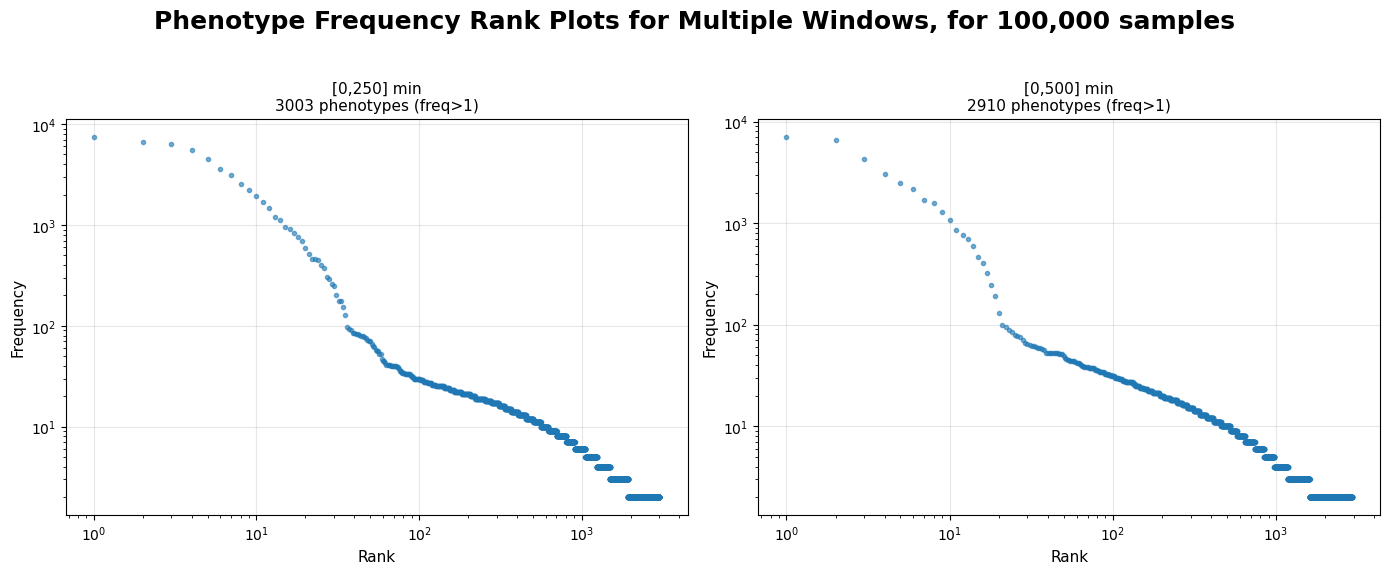


💾 Rank plots saved: plots/chico_multi_window_rank_plots.png


In [28]:

fig_rank, axes_rank = plt.subplots(1, 2, figsize=(14, 6))
axes_rank = axes_rank.flatten()

for idx, window_data in enumerate(windows_data_storage):
    start, end = window_data['window']
    phenotype_counts = window_data['phenotype_counts']
    
    # Calculate rank-frequency from stored data (filter out frequency = 1)
    frequencies_filtered = [f for f in phenotype_counts.values() if f > 1]
    frequencies_sorted = sorted(frequencies_filtered, reverse=True)
    ranks = np.arange(1, len(frequencies_sorted) + 1)
    
    # Plot
    ax_rank = axes_rank[idx]
    ax_rank.loglog(ranks, frequencies_sorted, marker='o', linestyle='none', markersize=3, alpha=0.6)
    ax_rank.set_xlabel('Rank', fontsize=11)
    ax_rank.set_ylabel('Frequency', fontsize=11)
    ax_rank.set_title(f'[{start},{end}] min\n{len(frequencies_sorted)} phenotypes (freq>1)', fontsize=11)
    ax_rank.grid(True, alpha=0.3)

fig_rank.suptitle(f'Phenotype Frequency Rank Plots for Multiple Windows, for {SAMPLING_SIZE_WINDOWS:,} samples', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('plots/chico_multi_window_rank_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Rank plots saved: plots/chico_multi_window_rank_plots.png")
print(f"{'='*60}")




📊 OSCILLATION ANALYSIS SUMMARY



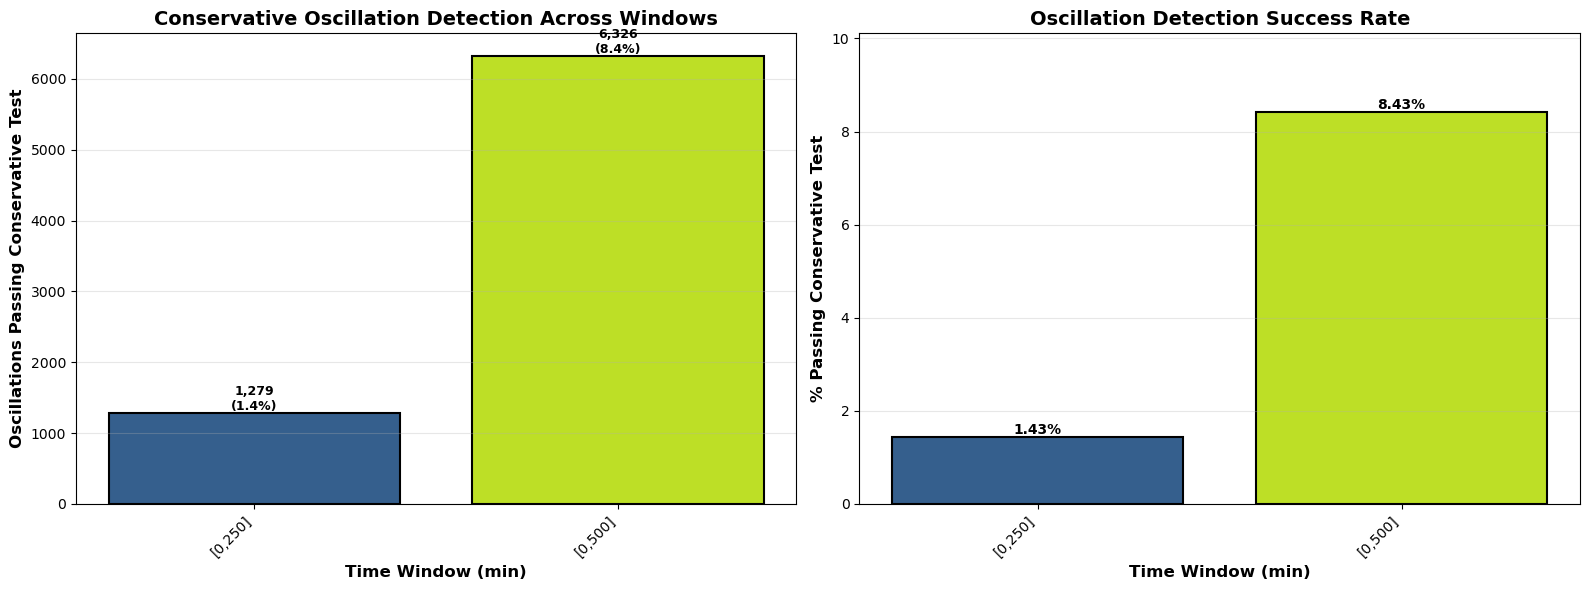


📋 SUMMARY TABLE:
Window          Total Success   Oscillations    Pass Rate 
------------------------------------------------------------
[  0,250] min  89,554          1,279             1.43%
[  0,500] min  75,080          6,326             8.43%

💾 Oscillation summary saved: plots/oscillation_pass_counts.png


In [29]:
# === OSCILLATION PASS COUNT VISUALIZATION ===
print(f"\n{'='*60}")
print("📊 OSCILLATION ANALYSIS SUMMARY")
print(f"{'='*60}\n")

# Create bar plot of oscillation pass counts per window
fig_osc, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart of oscillation pass counts
window_labels = [f"[{start},{end}]" for start, end in windows]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(windows)))

bars = ax1.bar(range(len(windows)), oscillation_pass_counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Time Window (min)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Oscillations Passing Conservative Test', fontsize=12, fontweight='bold')
ax1.set_title('Conservative Oscillation Detection Across Windows', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(windows)))
ax1.set_xticklabels(window_labels, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, oscillation_pass_counts)):
    height = bar.get_height()
    success = windows_data_storage[i]['success_count']
    percentage = count / success * 100 if success > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Percentage of oscillations per window
percentages = [windows_data_storage[i]['oscillation_pass_count'] / windows_data_storage[i]['success_count'] * 100 
               if windows_data_storage[i]['success_count'] > 0 else 0 
               for i in range(len(windows))]

bars2 = ax2.bar(range(len(windows)), percentages, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Time Window (min)', fontsize=12, fontweight='bold')
ax2.set_ylabel('% Passing Conservative Test', fontsize=12, fontweight='bold')
ax2.set_title('Oscillation Detection Success Rate', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(windows)))
ax2.set_xticklabels(window_labels, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(percentages) * 1.2 if percentages else 1)

# Add value labels
for bar, pct in zip(bars2, percentages):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/oscillation_pass_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\n📋 SUMMARY TABLE:")
print(f"{'Window':<15} {'Total Success':<15} {'Oscillations':<15} {'Pass Rate':<10}")
print("-" * 60)
for i, (start, end) in enumerate(windows):
    success = windows_data_storage[i]['success_count']
    osc_count = windows_data_storage[i]['oscillation_pass_count']
    pct = osc_count / success * 100 if success > 0 else 0
    print(f"[{start:3d},{end:3d}] min  {success:<15,} {osc_count:<15,} {pct:>6.2f}%")

print(f"\n💾 Oscillation summary saved: plots/oscillation_pass_counts.png")
print(f"{'='*60}")


📊 CALCULATING RMSE BETWEEN MIDDLE TWO PEAK PERIODS IN OSCILLATIONS

Window: [0, 500] min
Total oscillation examples available: 100

🔬 Calculating wildtype RMS for comparison...
   Wildtype peaks found: 5
   Middle peak indices: 1, 2
   Estimated period: 101.25 min
   Peak values: 1.4290, 1.4271
   Integration window: ±50.62 min around each peak
   Wildtype RMSE (waveform comparison): 0.0055


❌ REJECTED SAMPLES ANALYSIS (2 rejected)

Rejection reasons:
   • Not enough peaks: 2

📋 Details of first 5 rejected samples:
----------------------------------------------------------------------

Example 56:
   Reason: Not enough peaks (0 < 2)
   Num peaks detected: 0
   Time range: [0.0, 500.0] min

Example 91:
   Reason: Not enough peaks (1 < 2)
   Num peaks detected: 1
   Time range: [0.0, 500.0] min


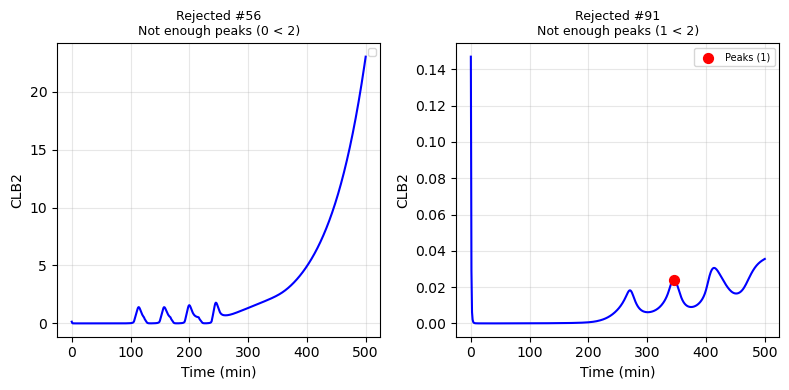


💾 Rejected examples plot saved: plots/rejected_rmse_examples.png


📋 RMSE Results for Middle Two Peak Periods:

Example    Num Peaks    Period       Peak 1       Peak 2       RMSE        
------------------------------------------------------------------------
0          5            88.50        0.5752       1.0051       0.1159      
1          3            174.50       1.3875       0.9412       0.4111      
2          5            67.00        1.8794       2.0245       0.0737      
3          5            87.75        4.8768       5.9826       0.4500      
4          6            88.60        0.6010       0.5813       0.0091      
5          6            69.00        1.4663       1.4701       0.0651      
6          3            92.50        3.0076       4.2486       0.5122      
7          5            96.75        0.5854       0.6716       0.0452      
8          6            73.20        2.3719       2.4682       0.0568      
9          5            77.00        2.4352       2.68

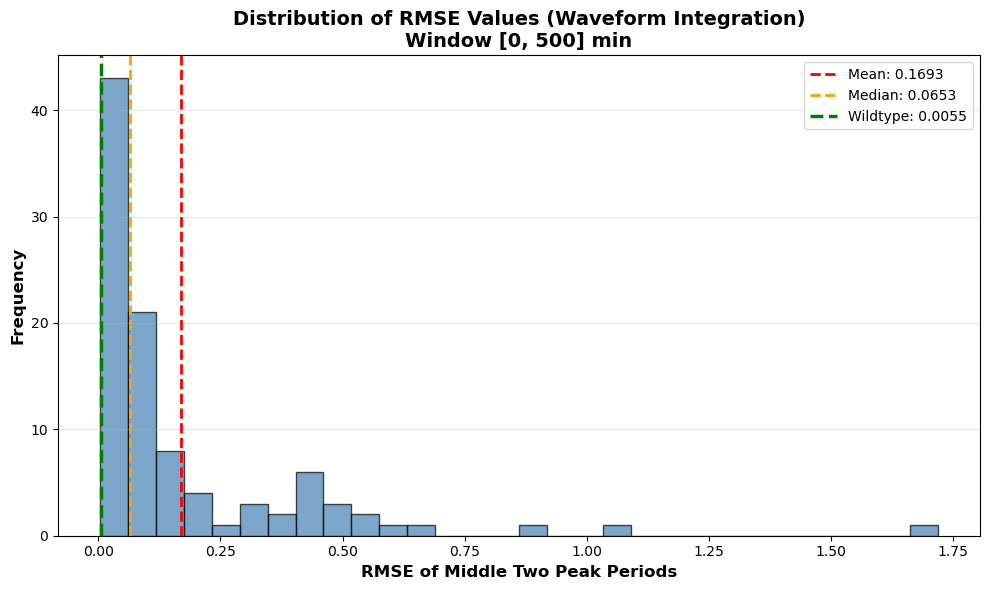


💾 RMSE histogram saved: plots/rmse_middle_two_peak_periods_histogram.png

📊 Wildtype Comparison:
   Wildtype RMSE: 0.0055
   Percentile: 2.04% (wildtype is at 2.0th percentile of distribution)
   → Wildtype RMSE is in the LOWER quartile (more consistent oscillations)



In [32]:
# === RMSE CALCULATION FOR MIDDLE TWO PEAK PERIODS ===
print(f"\n{'='*60}")
print("📊 CALCULATING RMSE BETWEEN MIDDLE TWO PEAK PERIODS IN OSCILLATIONS")
print(f"{'='*60}\n")

from scipy.signal import find_peaks
from scipy.integrate import simpson

# Get oscillation examples from the last window
last_window_data = windows_data_storage[-1]
last_window = last_window_data['window']
oscillation_examples = last_window_data['oscillation_examples']

print(f"Window: [{last_window[0]}, {last_window[1]}] min")
print(f"Total oscillation examples available: {len(oscillation_examples)}")

# === CALCULATE WILDTYPE RMS ===
print(f"\n🔬 Calculating wildtype RMS for comparison...")
try:
    # Get wildtype data for the last window
    rr_wt_rms = te.loadSBMLModel(model_path)
    sample_parameters(rr_wt_rms, wildtype=True)
    wt_time, wt_clb2, _, _, _ = simulate_and_extract_chico(rr_wt_rms, T=last_window[1], CoarseStart=last_window[0])
    
    if wt_time is not None and not isinstance(wt_time, str):
        wt_time_arr = np.asarray(wt_time)
        wt_clb2_arr = np.asarray(wt_clb2)
        
        # Find peaks in wildtype signal
        wt_peaks, _ = find_peaks(wt_clb2_arr, prominence=0.1 * (np.max(wt_clb2_arr) - np.min(wt_clb2_arr)))
        
        if len(wt_peaks) >= 2:
            # Use middle two peaks instead of last two
            n_peaks = len(wt_peaks)
            if n_peaks % 2 == 0:
                # Even number of peaks: take the two middle ones
                mid_idx = n_peaks // 2
                peak_idx1, peak_idx2 = mid_idx - 1, mid_idx
            else:
                # Odd number of peaks: take middle-1 and middle
                mid_idx = n_peaks // 2
                peak_idx1, peak_idx2 = mid_idx - 1, mid_idx
            
            # Estimate period from peak spacing
            peak_times = wt_time_arr[wt_peaks]
            estimated_period = np.mean(np.diff(peak_times))
            
            # Extract waveforms: ±0.5*period around each peak
            half_period = 0.5 * estimated_period
            
            # First peak period
            t_center1 = wt_time_arr[wt_peaks[peak_idx1]]
            mask1 = (wt_time_arr >= t_center1 - half_period) & (wt_time_arr <= t_center1 + half_period)
            t1 = wt_time_arr[mask1]
            signal1 = wt_clb2_arr[mask1]
            
            # Second peak period
            t_center2 = wt_time_arr[wt_peaks[peak_idx2]]
            mask2 = (wt_time_arr >= t_center2 - half_period) & (wt_time_arr <= t_center2 + half_period)
            t2 = wt_time_arr[mask2]
            signal2 = wt_clb2_arr[mask2]
            
            # Calculate RMSE between the two waveforms
            # Align both to start at t=0
            t1_aligned = t1 - t1[0]
            t2_aligned = t2 - t2[0]
            
            # Interpolate to common time grid
            common_t = np.linspace(0, min(t1_aligned[-1], t2_aligned[-1]), 100)
            signal1_interp = np.interp(common_t, t1_aligned, signal1)
            signal2_interp = np.interp(common_t, t2_aligned, signal2)
            
            # Calculate RMSE: sqrt(1/T * integral((x(t) - y(t))^2 dt))
            squared_diff = (signal1_interp - signal2_interp)**2
            T_integration = common_t[-1] - common_t[0]
            wt_rmse = np.sqrt(simpson(squared_diff, common_t) / T_integration)
            
            wt_peak1, wt_peak2 = wt_clb2_arr[wt_peaks[peak_idx1]], wt_clb2_arr[wt_peaks[peak_idx2]]
            
            print(f"   Wildtype peaks found: {len(wt_peaks)}")
            print(f"   Middle peak indices: {peak_idx1}, {peak_idx2}")
            print(f"   Estimated period: {estimated_period:.2f} min")
            print(f"   Peak values: {wt_peak1:.4f}, {wt_peak2:.4f}")
            print(f"   Integration window: ±{half_period:.2f} min around each peak")
            print(f"   Wildtype RMSE (waveform comparison): {wt_rmse:.4f}")
        else:
            wt_rmse = None
            print(f"   ⚠️ Wildtype has < 2 peaks ({len(wt_peaks)} peaks found)")
    else:
        wt_rmse = None
        print(f"   ⚠️ Wildtype simulation failed")
except Exception as e:
    wt_rmse = None
    print(f"   ⚠️ Error calculating wildtype RMSE: {e}")

print()

if len(oscillation_examples) > 0:
    # Calculate RMSE for each example
    rmse_results = []
    rejected_examples = []  # Track rejected samples with reasons
    
    for idx, example in enumerate(oscillation_examples):
        time_data = np.asarray(example['time_data'])
        clb2_data = np.asarray(example['clb2_data'])
        
        # Find peaks in the signal
        data_range = np.max(clb2_data) - np.min(clb2_data)
        peaks, _ = find_peaks(clb2_data, 
                             prominence=0.1*data_range,
                             distance=len(clb2_data)//50,
                             width=5)
        
        if len(peaks) >= 2:
            # Use middle two peaks
            n_peaks = len(peaks)
            if n_peaks % 2 == 0:
                mid_idx = n_peaks // 2
                peak_idx1, peak_idx2 = mid_idx - 1, mid_idx
            else:
                mid_idx = n_peaks // 2
                peak_idx1, peak_idx2 = mid_idx - 1, mid_idx
            
            # Estimate period from peak spacing
            peak_times = time_data[peaks]
            estimated_period = np.mean(np.diff(peak_times))
            
            # Extract waveforms: ±0.5*period around each peak
            half_period = 0.5 * estimated_period
            
            # First peak period
            t_center1 = time_data[peaks[peak_idx1]]
            mask1 = (time_data >= t_center1 - half_period) & (time_data <= t_center1 + half_period)
            t1 = time_data[mask1]
            signal1 = clb2_data[mask1]
            
            # Second peak period
            t_center2 = time_data[peaks[peak_idx2]]
            mask2 = (time_data >= t_center2 - half_period) & (time_data <= t_center2 + half_period)
            t2 = time_data[mask2]
            signal2 = clb2_data[mask2]
            
            if len(t1) > 0 and len(t2) > 0:
                # Calculate RMSE between the two waveforms
                # Align both to start at t=0
                t1_aligned = t1 - t1[0]
                t2_aligned = t2 - t2[0]
                
                # Interpolate to common time grid
                common_t = np.linspace(0, min(t1_aligned[-1], t2_aligned[-1]), 100)
                signal1_interp = np.interp(common_t, t1_aligned, signal1)
                signal2_interp = np.interp(common_t, t2_aligned, signal2)
                
                # Calculate RMSE: sqrt(1/T * integral((x(t) - y(t))^2 dt))
                squared_diff = (signal1_interp - signal2_interp)**2
                T_integration = common_t[-1] - common_t[0]
                rmse = np.sqrt(simpson(squared_diff, common_t) / T_integration)
                
                peak1, peak2 = clb2_data[peaks[peak_idx1]], clb2_data[peaks[peak_idx2]]
                
                rmse_results.append({
                    'example_idx': idx,
                    'peak1': peak1,
                    'peak2': peak2,
                    'rmse': rmse,
                    'num_peaks': len(peaks),
                    'period': estimated_period
                })
            else:
                # Rejected: empty waveform window
                rejected_examples.append({
                    'example_idx': idx,
                    'reason': 'Empty waveform window',
                    'num_peaks': len(peaks),
                    'period': estimated_period,
                    'peak1_center': t_center1,
                    'peak2_center': t_center2,
                    'half_period': half_period,
                    'time_range': (time_data[0], time_data[-1]),
                    'len_t1': len(t1),
                    'len_t2': len(t2),
                    'time_data': time_data,
                    'clb2_data': clb2_data,
                    'peaks': peaks
                })
                rmse_results.append({
                    'example_idx': idx,
                    'peak1': None,
                    'peak2': None,
                    'rmse': None,
                    'num_peaks': len(peaks),
                    'period': None
                })
        else:
            # Rejected: not enough peaks
            rejected_examples.append({
                'example_idx': idx,
                'reason': f'Not enough peaks ({len(peaks)} < 2)',
                'num_peaks': len(peaks),
                'time_range': (time_data[0], time_data[-1]),
                'time_data': time_data,
                'clb2_data': clb2_data,
                'peaks': peaks
            })
            rmse_results.append({
                'example_idx': idx,
                'peak1': None,
                'peak2': None,
                'rmse': None,
                'num_peaks': len(peaks),
                'period': None
            })
    
    # === PRINT REJECTED EXAMPLES ===
    print(f"\n{'='*60}")
    print(f"❌ REJECTED SAMPLES ANALYSIS ({len(rejected_examples)} rejected)")
    print(f"{'='*60}")
    
    if len(rejected_examples) > 0:
        # Count by reason
        reason_counts = {}
        for r in rejected_examples:
            reason = r['reason'].split('(')[0].strip()  # Group similar reasons
            reason_counts[reason] = reason_counts.get(reason, 0) + 1
        
        print(f"\nRejection reasons:")
        for reason, count in reason_counts.items():
            print(f"   • {reason}: {count}")
        
        # Show details of first few rejected
        print(f"\n📋 Details of first 5 rejected samples:")
        print("-" * 70)
        for i, rej in enumerate(rejected_examples[:5]):
            print(f"\nExample {rej['example_idx']}:")
            print(f"   Reason: {rej['reason']}")
            print(f"   Num peaks detected: {rej['num_peaks']}")
            print(f"   Time range: [{rej['time_range'][0]:.1f}, {rej['time_range'][1]:.1f}] min")
            if 'period' in rej and rej.get('period'):
                print(f"   Estimated period: {rej['period']:.1f} min")
                print(f"   Half period (window): ±{rej['half_period']:.1f} min")
            if 'peak1_center' in rej:
                print(f"   Peak 1 center: {rej['peak1_center']:.1f} min (window: [{rej['peak1_center']-rej['half_period']:.1f}, {rej['peak1_center']+rej['half_period']:.1f}])")
                print(f"   Peak 2 center: {rej['peak2_center']:.1f} min (window: [{rej['peak2_center']-rej['half_period']:.1f}, {rej['peak2_center']+rej['half_period']:.1f}])")
                print(f"   Points in window 1: {rej['len_t1']}, Points in window 2: {rej['len_t2']}")
        
        # Plot a few rejected examples
        n_plot = min(4, len(rejected_examples))
        if n_plot > 0:
            fig_rej, axes_rej = plt.subplots(1, n_plot, figsize=(4*n_plot, 4))
            if n_plot == 1:
                axes_rej = [axes_rej]
            
            for i, rej in enumerate(rejected_examples[:n_plot]):
                ax = axes_rej[i]
                ax.plot(rej['time_data'], rej['clb2_data'], 'b-', linewidth=1.5)
                
                # Mark detected peaks
                if len(rej['peaks']) > 0:
                    ax.scatter(rej['time_data'][rej['peaks']], rej['clb2_data'][rej['peaks']], 
                              color='red', s=50, zorder=5, label=f"Peaks ({len(rej['peaks'])})")
                
                # Show extraction windows if available
                if 'half_period' in rej:
                    ax.axvspan(rej['peak1_center'] - rej['half_period'], 
                              rej['peak1_center'] + rej['half_period'], 
                              alpha=0.2, color='green', label='Window 1')
                    ax.axvspan(rej['peak2_center'] - rej['half_period'], 
                              rej['peak2_center'] + rej['half_period'], 
                              alpha=0.2, color='orange', label='Window 2')
                
                ax.set_xlabel('Time (min)', fontsize=10)
                ax.set_ylabel('CLB2', fontsize=10)
                ax.set_title(f"Rejected #{rej['example_idx']}\n{rej['reason']}", fontsize=9)
                ax.legend(fontsize=7, loc='upper right')
                ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('plots/rejected_rmse_examples.png', dpi=150, bbox_inches='tight')
            plt.show()
            print(f"\n💾 Rejected examples plot saved: plots/rejected_rmse_examples.png")
    else:
        print("   No rejected samples! All passed RMSE calculation.")
    
    print(f"\n{'='*60}")
    
    # Display results
    print(f"\n📋 RMSE Results for Middle Two Peak Periods:\n")
    print(f"{'Example':<10} {'Num Peaks':<12} {'Period':<12} {'Peak 1':<12} {'Peak 2':<12} {'RMSE':<12}")
    print("-" * 72)
    
    valid_rmse_count = 0
    for result in rmse_results[:20]:  # Show first 20 examples
        idx = result['example_idx']
        num_peaks = result['num_peaks']
        peak1 = result['peak1']
        peak2 = result['peak2']
        rmse = result['rmse']
        period = result['period']
        
        if rmse is not None:
            print(f"{idx:<10} {num_peaks:<12} {period:<12.2f} {peak1:<12.4f} {peak2:<12.4f} {rmse:<12.4f}")
            valid_rmse_count += 1
        else:
            print(f"{idx:<10} {num_peaks:<12} {'N/A':<12} {'N/A':<12} {'N/A':<12} {'N/A':<12}")
    
    if len(rmse_results) > 20:
        print(f"... and {len(rmse_results) - 20} more examples")
    
    # Calculate statistics on valid RMSE values
    valid_rmse = [r['rmse'] for r in rmse_results if r['rmse'] is not None]
    
    if valid_rmse:
        # Calculate how many fall below threshold
        rmse_threshold = 0.05
        below_threshold = np.sum(np.array(valid_rmse) < rmse_threshold)
        below_threshold_pct = (below_threshold / len(valid_rmse)) * 100
        
        print(f"\n📊 RMSE Statistics:")
        print(f"   Valid calculations: {len(valid_rmse)}/{len(rmse_results)}")
        print(f"   Mean RMSE: {np.mean(valid_rmse):.4f}")
        print(f"   Std RMSE: {np.std(valid_rmse):.4f}")
        print(f"   Min RMSE: {np.min(valid_rmse):.4f}")
        print(f"   Max RMSE: {np.max(valid_rmse):.4f}")
        print(f"   Median RMSE: {np.median(valid_rmse):.4f}")
        print(f"\n   🎯 RMSE < {rmse_threshold}: {below_threshold}/{len(valid_rmse)} ({below_threshold_pct:.2f}%)")
        
        # Create histogram of RMSE values
        fig_rms, ax_rms = plt.subplots(1, 1, figsize=(10, 6))
        ax_rms.hist(valid_rmse, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        ax_rms.set_xlabel('RMSE of Middle Two Peak Periods', fontsize=12, fontweight='bold')
        ax_rms.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax_rms.set_title(f'Distribution of RMSE Values (Waveform Integration)\nWindow [{last_window[0]}, {last_window[1]}] min',
                        fontsize=14, fontweight='bold')
        ax_rms.grid(True, alpha=0.3, axis='y')
        ax_rms.axvline(np.mean(valid_rmse), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(valid_rmse):.4f}')
        ax_rms.axvline(np.median(valid_rmse), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(valid_rmse):.4f}')
        
        # Add wildtype RMSE if available
        if wt_rmse is not None:
            ax_rms.axvline(wt_rmse, color='green', linestyle='--', linewidth=2.5, label=f'Wildtype: {wt_rmse:.4f}')
        
        ax_rms.legend()
        
        plt.tight_layout()
        plt.savefig('plots/rmse_middle_two_peak_periods_histogram.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n💾 RMSE histogram saved: plots/rmse_middle_two_peak_periods_histogram.png")
        
        # Compare wildtype to distribution
        if wt_rmse is not None:
            percentile = (np.sum(np.array(valid_rmse) <= wt_rmse) / len(valid_rmse)) * 100
            print(f"\n📊 Wildtype Comparison:")
            print(f"   Wildtype RMSE: {wt_rmse:.4f}")
            print(f"   Percentile: {percentile:.2f}% (wildtype is at {percentile:.1f}th percentile of distribution)")
            if percentile < 25:
                print(f"   → Wildtype RMSE is in the LOWER quartile (more consistent oscillations)")
            elif percentile < 50:
                print(f"   → Wildtype RMSE is in the LOWER-MIDDLE quartile")
            elif percentile < 75:
                print(f"   → Wildtype RMSE is in the UPPER-MIDDLE quartile")
            else:
                print(f"   → Wildtype RMSE is in the UPPER quartile (less consistent oscillations)")
    else:
        print(f"\n⚠️  No valid RMSE calculations (all examples had < 2 peaks)")
        
else:
    print("⚠️  No oscillation examples found for the last window!")

print(f"\n{'='*60}")


🔬 VISUALIZING HIGH-QUALITY OSCILLATIONS (RMSE ≤ 0.05)

Total oscillation examples: 100
High-quality examples (RMSE ≤ 0.05): 41
Percentage: 41.00%

Showing 9 randomly selected high-quality examples



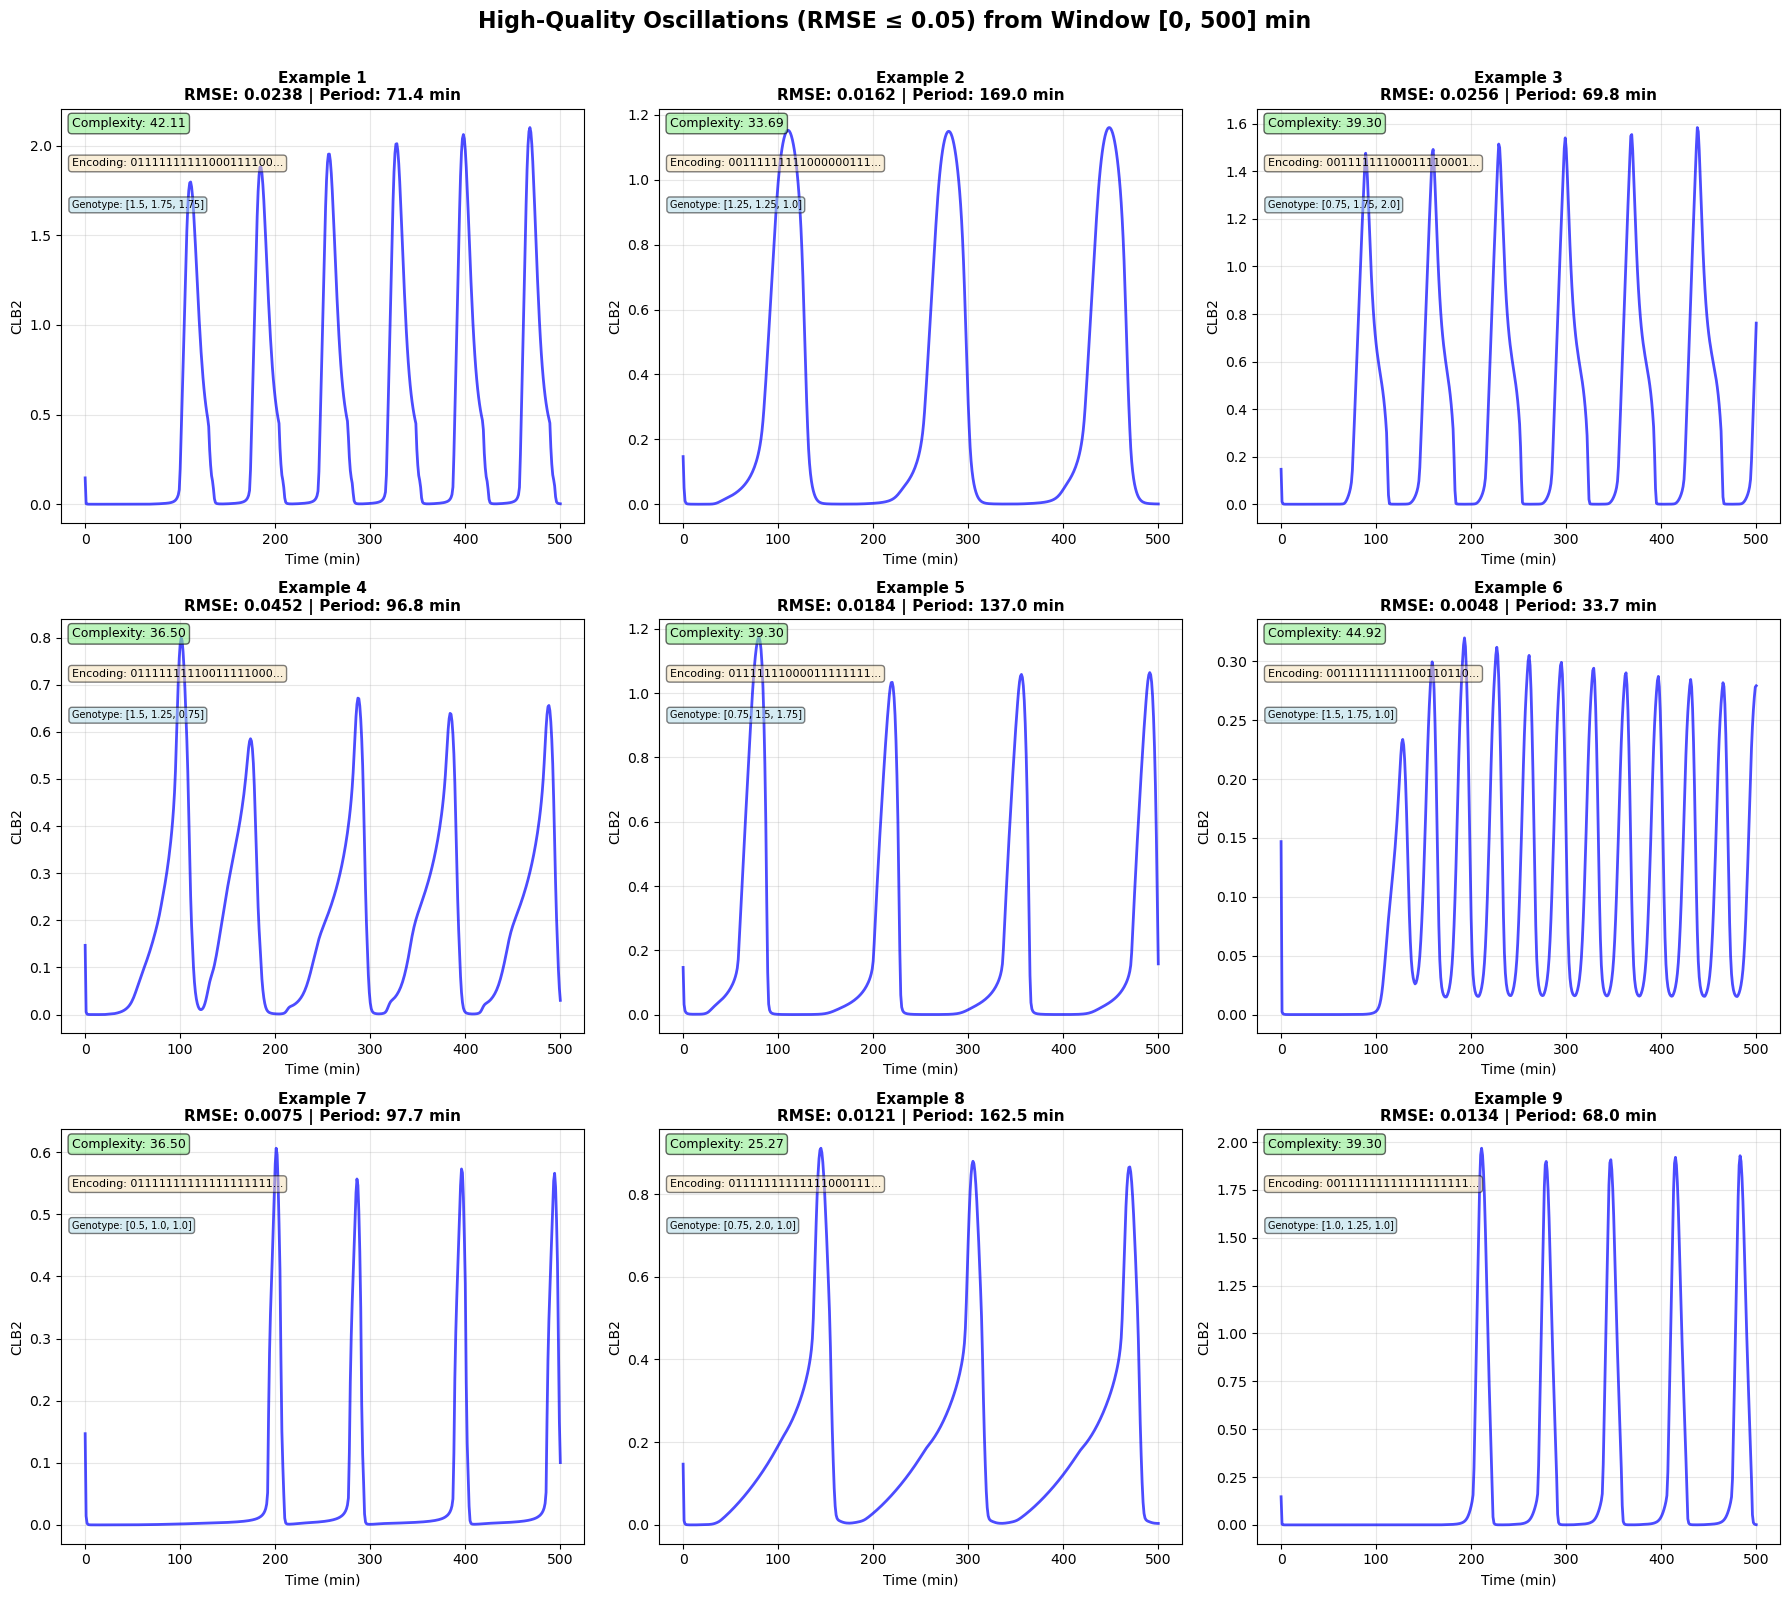

💾 High-quality oscillations saved: plots/high_quality_oscillations_rmse_filtered.png

📋 Details of shown examples:
   Example 1: RMSE=0.0238, Period=71.4 min, Complexity=42.110, Encoding length=49
   Example 2: RMSE=0.0162, Period=169.0 min, Complexity=33.688, Encoding length=49
   Example 3: RMSE=0.0256, Period=69.8 min, Complexity=39.303, Encoding length=49
   Example 4: RMSE=0.0452, Period=96.8 min, Complexity=36.496, Encoding length=49
   Example 5: RMSE=0.0184, Period=137.0 min, Complexity=39.303, Encoding length=49
   Example 6: RMSE=0.0048, Period=33.7 min, Complexity=44.918, Encoding length=49
   Example 7: RMSE=0.0075, Period=97.7 min, Complexity=36.496, Encoding length=49
   Example 8: RMSE=0.0121, Period=162.5 min, Complexity=25.266, Encoding length=49
   Example 9: RMSE=0.0134, Period=68.0 min, Complexity=39.303, Encoding length=49



In [37]:
# === 3x3 EXAMPLE OSCILLATIONS WITH RMSE ≤ 0.05 ===
print(f"\n{'='*60}")
print("🔬 VISUALIZING HIGH-QUALITY OSCILLATIONS (RMSE ≤ 0.05)")
print(f"{'='*60}\n")

# Filter oscillation examples to those with RMSE ≤ 0.05
rmse_threshold = 0.05
high_quality_examples = []

for result in rmse_results:
    if result['rmse'] is not None and result['rmse'] <= rmse_threshold:
        example_idx = result['example_idx']
        example = oscillation_examples[example_idx]
        # Add RMSE info to the example
        example_with_rmse = example.copy()
        example_with_rmse['rmse'] = result['rmse']
        example_with_rmse['period'] = result['period']
        high_quality_examples.append(example_with_rmse)

print(f"Total oscillation examples: {len(oscillation_examples)}")
print(f"High-quality examples (RMSE ≤ {rmse_threshold}): {len(high_quality_examples)}")
print(f"Percentage: {(len(high_quality_examples)/len(oscillation_examples)*100):.2f}%\n")

if len(high_quality_examples) > 0:
    # Randomly select up to 9 examples
    import random
    n_to_show = min(9, len(high_quality_examples))
    selected_indices = random.sample(range(len(high_quality_examples)), n_to_show)
    selected_examples = [high_quality_examples[i] for i in selected_indices]
    
    print(f"Showing {n_to_show} randomly selected high-quality examples\n")
    
    # Create 3x3 subplot
    fig_hq, axes_hq = plt.subplots(3, 3, figsize=(18, 16))
    axes_hq = axes_hq.flatten()
    
    for idx, example in enumerate(selected_examples):
        ax = axes_hq[idx]
        
        time_data = example['time_data']
        clb2_data = example['clb2_data']
        complexity = example['complexity']
        encoding = example['encoding']
        genotype = example['genotype']
        rmse = example['rmse']
        period = example['period']
        
        # Plot the time series
        ax.plot(time_data, clb2_data, 'b-', linewidth=2, alpha=0.7)
        ax.set_xlabel('Time (min)', fontsize=10)
        ax.set_ylabel('CLB2', fontsize=10)
        ax.set_title(f'Example {idx+1}\nRMSE: {rmse:.4f} | Period: {period:.1f} min', 
                    fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add complexity info
        ax.text(0.02, 0.98, f'Complexity: {complexity:.2f}',
               transform=ax.transAxes, fontsize=9,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.6))
        
        # Add encoding info as text
        encoding_display = encoding[:20] + '...' if len(encoding) > 20 else encoding
        ax.text(0.02, 0.88, f'Encoding: {encoding_display}',
               transform=ax.transAxes, fontsize=8,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Add genotype info
        genotype_str = f"Genotype: {genotype[:3]}" if len(genotype) > 3 else f"Genotype: {genotype}"
        ax.text(0.02, 0.78, genotype_str,
               transform=ax.transAxes, fontsize=7,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    # Hide unused subplots if less than 9 examples
    for idx in range(n_to_show, 9):
        axes_hq[idx].axis('off')
    
    fig_hq.suptitle(f'High-Quality Oscillations (RMSE ≤ {rmse_threshold}) from Window [{last_window[0]}, {last_window[1]}] min',
                    fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.savefig('plots/high_quality_oscillations_rmse_filtered.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"💾 High-quality oscillations saved: plots/high_quality_oscillations_rmse_filtered.png")
    
    # Print details of shown examples
    print(f"\n📋 Details of shown examples:")
    for idx, example in enumerate(selected_examples):
        print(f"   Example {idx+1}: RMSE={example['rmse']:.4f}, Period={example['period']:.1f} min, "
              f"Complexity={example['complexity']:.3f}, "
              f"Encoding length={len(example['encoding'])}")
else:
    print("⚠️  No high-quality oscillation examples found (all RMSE > 0.05)!")
    print("   Try using a less stringent threshold")

print(f"\n{'='*60}")


📊 PERIOD DISTRIBUTION FOR HIGH-QUALITY OSCILLATIONS (RMSE ≤ 0.05)

Total high-quality oscillations: 41
Period range: [24.1, 183.5] min
Mean period: 107.4 ± 38.8 min
Median period: 107.0 min

🎯 Periods in biologically relevant range [80, 110] min:
   Count: 10/41 (24.39%)

   Wildtype period: 84.7 min


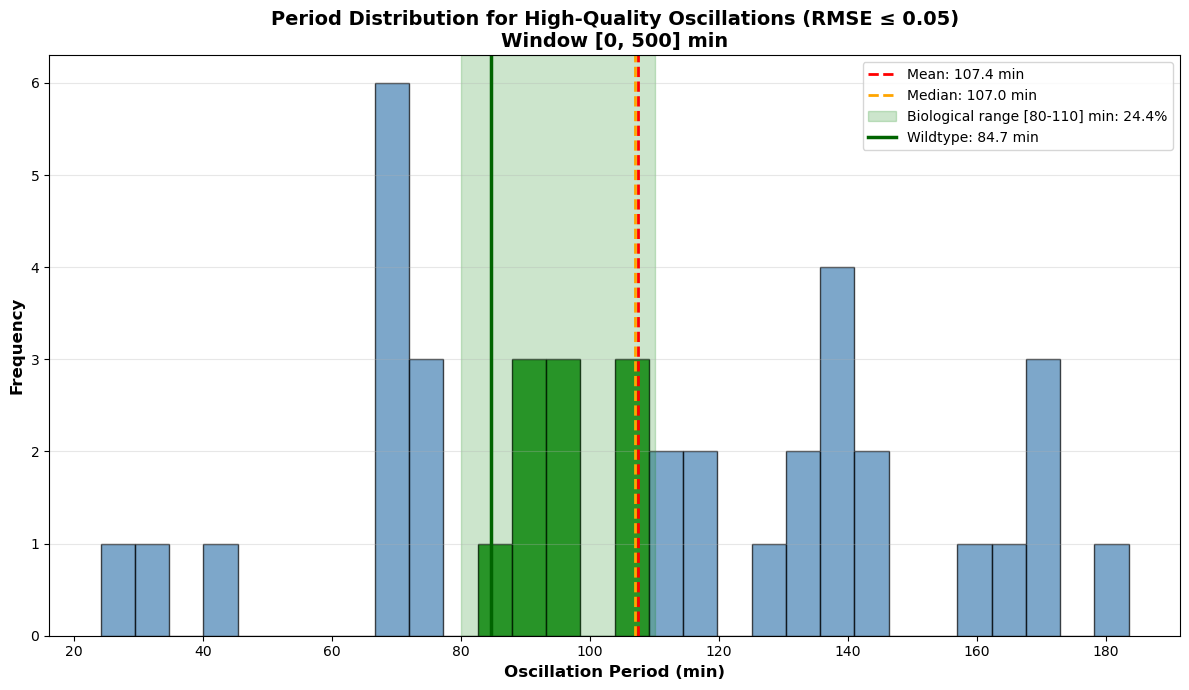


💾 Period distribution saved: plots/period_distribution_high_quality.png



In [35]:
# === PERIOD DISTRIBUTION FOR HIGH-QUALITY OSCILLATIONS ===
print(f"\n{'='*60}")
print("📊 PERIOD DISTRIBUTION FOR HIGH-QUALITY OSCILLATIONS (RMSE ≤ 0.05)")
print(f"{'='*60}\n")

if len(high_quality_examples) > 0:
    # Extract periods from high-quality examples
    hq_periods = [ex['period'] for ex in high_quality_examples]
    
    # Count periods in the biologically relevant range (80-110 min)
    period_min, period_max = 80, 110
    periods_in_range = np.sum((np.array(hq_periods) >= period_min) & (np.array(hq_periods) <= period_max))
    periods_in_range_pct = (periods_in_range / len(hq_periods)) * 100
    
    # Print statistics
    print(f"Total high-quality oscillations: {len(hq_periods)}")
    print(f"Period range: [{np.min(hq_periods):.1f}, {np.max(hq_periods):.1f}] min")
    print(f"Mean period: {np.mean(hq_periods):.1f} ± {np.std(hq_periods):.1f} min")
    print(f"Median period: {np.median(hq_periods):.1f} min")
    print(f"\n🎯 Periods in biologically relevant range [{period_min}, {period_max}] min:")
    print(f"   Count: {periods_in_range}/{len(hq_periods)} ({periods_in_range_pct:.2f}%)")
    
    # Create histogram of periods
    fig_period, ax_period = plt.subplots(1, 1, figsize=(12, 7))
    
    # Plot histogram
    counts, bins, patches = ax_period.hist(hq_periods, bins=30, color='steelblue', 
                                           edgecolor='black', alpha=0.7)
    
    # Highlight the biologically relevant range
    for i, patch in enumerate(patches):
        bin_center = (bins[i] + bins[i+1]) / 2
        if period_min <= bin_center <= period_max:
            patch.set_facecolor('green')
            patch.set_alpha(0.8)
    
    ax_period.set_xlabel('Oscillation Period (min)', fontsize=12, fontweight='bold')
    ax_period.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax_period.set_title(f'Period Distribution for High-Quality Oscillations (RMSE ≤ {rmse_threshold})\n'
                       f'Window [{last_window[0]}, {last_window[1]}] min',
                       fontsize=14, fontweight='bold')
    ax_period.grid(True, alpha=0.3, axis='y')
    
    # Add vertical lines for statistics
    ax_period.axvline(np.mean(hq_periods), color='red', linestyle='--', linewidth=2, 
                     label=f'Mean: {np.mean(hq_periods):.1f} min')
    ax_period.axvline(np.median(hq_periods), color='orange', linestyle='--', linewidth=2, 
                     label=f'Median: {np.median(hq_periods):.1f} min')
    
    # Add shaded region for biologically relevant range
    ax_period.axvspan(period_min, period_max, alpha=0.2, color='green', 
                     label=f'Biological range [{period_min}-{period_max}] min: {periods_in_range_pct:.1f}%')
    
    # Add wildtype period if available
    if wt_rmse is not None and wt_rmse <= rmse_threshold:
        # Calculate wildtype period from the peak times
        if len(wt_peaks) >= 2:
            wt_period = estimated_period
            ax_period.axvline(wt_period, color='darkgreen', linestyle='-', linewidth=2.5, 
                            label=f'Wildtype: {wt_period:.1f} min')
            print(f"\n   Wildtype period: {wt_period:.1f} min")
    
    ax_period.legend(fontsize=10, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('plots/period_distribution_high_quality.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Period distribution saved: plots/period_distribution_high_quality.png")
    
else:
    print("⚠️  No high-quality oscillations to analyze!")

print(f"\n{'='*60}")

📊 BIOLOGICAL PHENOTYPE FILTERING FUNNEL - SUMMARY STATISTICS

📋 Window: [0, 500] min

⚠️  NOTE: RMSE analysis based on 100 stored examples (extrapolated to full population)

🔻 FILTERING FUNNEL (with extrapolation):
   ┌─────────────────────────────────────────────────────────────┐
   │ 1. TOTAL SAMPLES (non-divergent)                           │
   │        75,080 samples                                   │
   └────────────────────────┬────────────────────────────────────┘
                            ▼
   ┌─────────────────────────────────────────────────────────────┐
   │ 2. OSCILLATION PASS (conservative peak detection)          │
   │         6,326 samples ( 8.43% of total)           │
   └────────────────────────┬────────────────────────────────────┘
                            ▼
   ┌─────────────────────────────────────────────────────────────┐
   │ 3. GOOD RMS (RMSE ≤ 0.05)                                   │
   │    Sample: 41/100 = 41.00%                            │
   │    ★ 

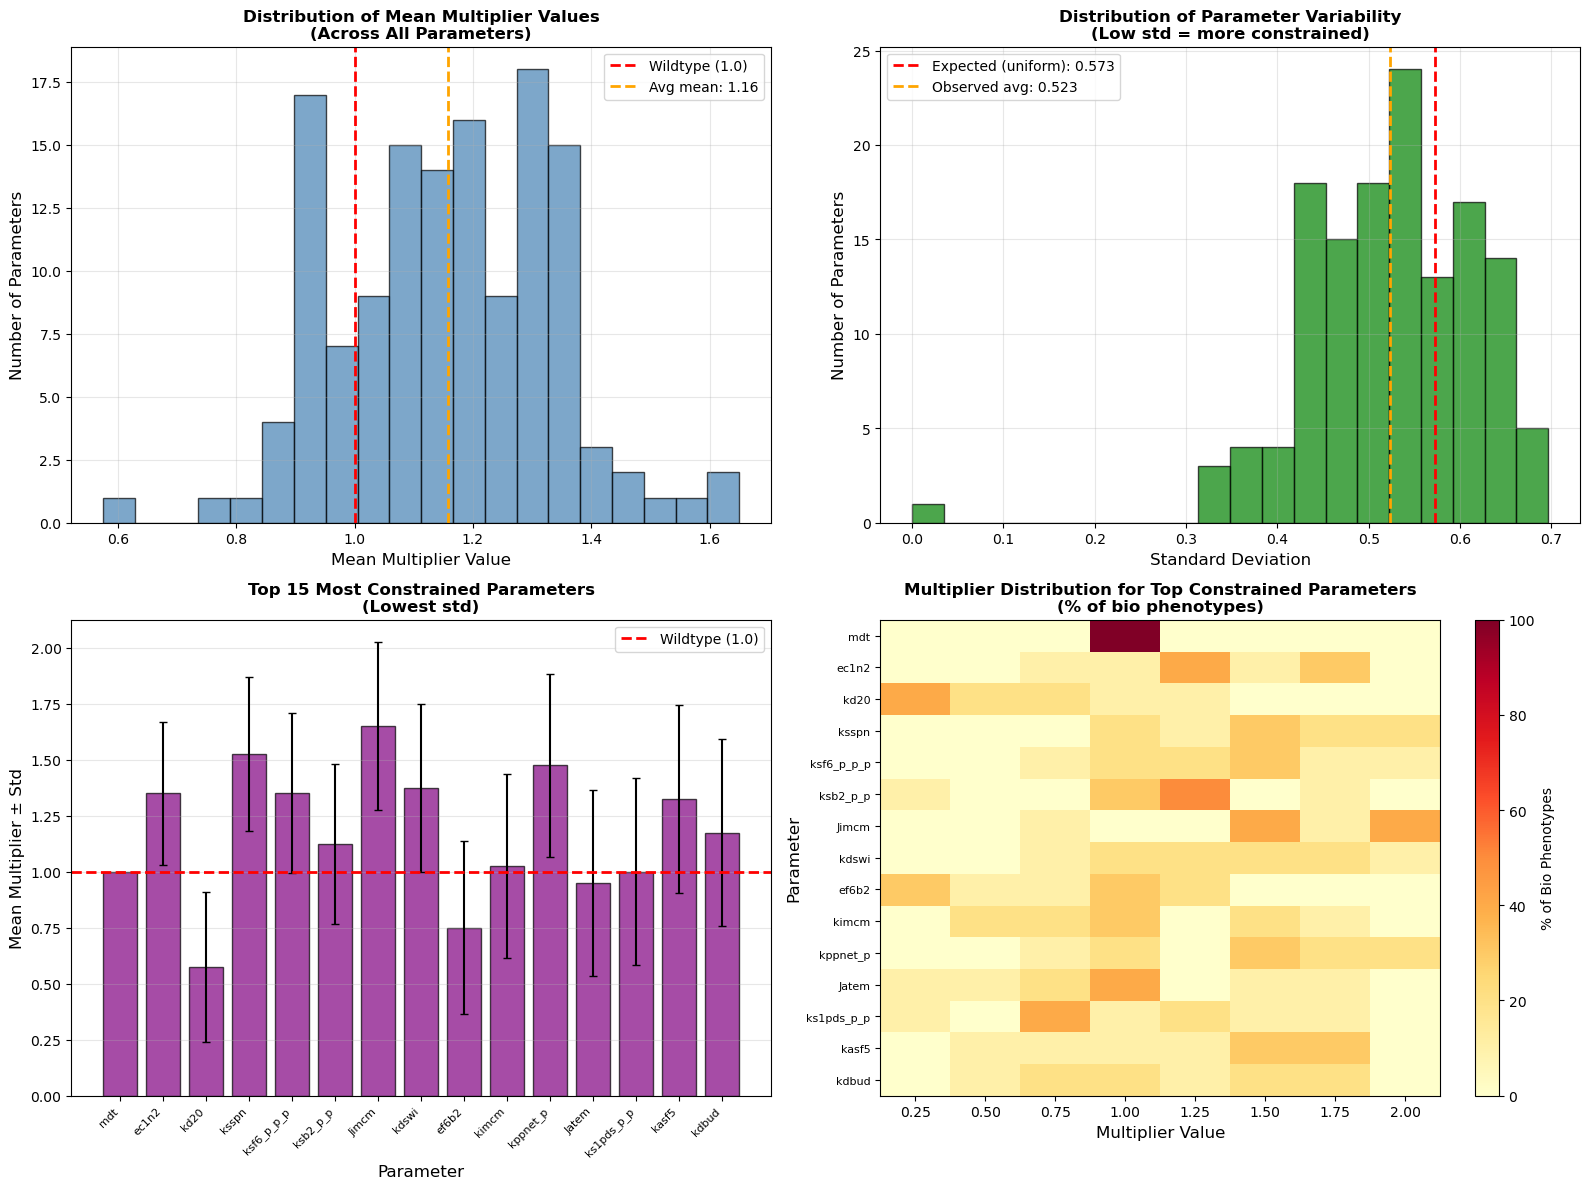


💾 Parameter analysis saved: plots/parameter_space_analysis.png

✅ ANALYSIS COMPLETE!


In [38]:
# === FINAL STATISTICS & PARAMETER SPACE ANALYSIS ===
print("="*70)
print("📊 BIOLOGICAL PHENOTYPE FILTERING FUNNEL - SUMMARY STATISTICS")
print("="*70)

# Get data from the last window (where we have oscillation examples with genotypes)
last_window_data = windows_data_storage[-1]
last_window = last_window_data['window']
total_success = last_window_data['success_count']
oscillation_pass = last_window_data['oscillation_pass_count']
oscillation_examples = last_window_data['oscillation_examples']

# Count RMSE-passing examples
rmse_threshold = 0.05
period_min, period_max = 80, 110

# Re-calculate RMSE for all oscillation examples to ensure we have the data
good_rmse_examples = []
bio_phenotype_examples = []

for idx, example in enumerate(oscillation_examples):
    time_data = np.asarray(example['time_data'])
    clb2_data = np.asarray(example['clb2_data'])
    genotype = example['genotype']
    
    # Find peaks
    data_range = np.max(clb2_data) - np.min(clb2_data)
    peaks, _ = find_peaks(clb2_data, prominence=0.1*data_range, distance=len(clb2_data)//50, width=5)
    
    if len(peaks) >= 2:
        # Calculate period
        peak_times = time_data[peaks]
        period = np.mean(np.diff(peak_times))
        
        # Calculate RMSE (simplified - compare middle two peak periods)
        n_peaks = len(peaks)
        mid_idx = n_peaks // 2
        peak_idx1, peak_idx2 = mid_idx - 1, mid_idx
        
        half_period = 0.5 * period
        t_center1 = time_data[peaks[peak_idx1]]
        t_center2 = time_data[peaks[peak_idx2]]
        
        mask1 = (time_data >= t_center1 - half_period) & (time_data <= t_center1 + half_period)
        mask2 = (time_data >= t_center2 - half_period) & (time_data <= t_center2 + half_period)
        
        t1, signal1 = time_data[mask1], clb2_data[mask1]
        t2, signal2 = time_data[mask2], clb2_data[mask2]
        
        if len(t1) > 0 and len(t2) > 0:
            from scipy.integrate import simpson
            t1_aligned = t1 - t1[0]
            t2_aligned = t2 - t2[0]
            common_t = np.linspace(0, min(t1_aligned[-1], t2_aligned[-1]), 100)
            signal1_interp = np.interp(common_t, t1_aligned, signal1)
            signal2_interp = np.interp(common_t, t2_aligned, signal2)
            squared_diff = (signal1_interp - signal2_interp)**2
            T_integration = common_t[-1] - common_t[0]
            rmse = np.sqrt(simpson(squared_diff, common_t) / T_integration)
            
            example_data = {
                'genotype': genotype,
                'rmse': rmse,
                'period': period,
                'complexity': example['complexity']
            }
            
            # Check if RMSE passes
            if rmse <= rmse_threshold:
                good_rmse_examples.append(example_data)
                
                # Check if period is in biological range
                if period_min <= period <= period_max:
                    bio_phenotype_examples.append(example_data)

# Calculate percentages from sample
n_sample = len(oscillation_examples)  # Should be 100
n_rmse_pass_sample = len(good_rmse_examples)
n_bio_phenotype_sample = len(bio_phenotype_examples)

# Calculate rates from the sample
rmse_pass_rate = n_rmse_pass_sample / n_sample if n_sample > 0 else 0
bio_rate_of_rmse = n_bio_phenotype_sample / n_rmse_pass_sample if n_rmse_pass_sample > 0 else 0

# EXTRAPOLATE to full oscillating population
n_rmse_pass_extrapolated = int(oscillation_pass * rmse_pass_rate)
n_bio_phenotype_extrapolated = int(n_rmse_pass_extrapolated * bio_rate_of_rmse)

print(f"\n📋 Window: [{last_window[0]}, {last_window[1]}] min")
print(f"\n⚠️  NOTE: RMSE analysis based on {n_sample} stored examples (extrapolated to full population)")
print(f"\n🔻 FILTERING FUNNEL (with extrapolation):")
print(f"   ┌─────────────────────────────────────────────────────────────┐")
print(f"   │ 1. TOTAL SAMPLES (non-divergent)                           │")
print(f"   │    {total_success:>10,} samples                                   │")
print(f"   └────────────────────────┬────────────────────────────────────┘")
print(f"                            ▼")
print(f"   ┌─────────────────────────────────────────────────────────────┐")
print(f"   │ 2. OSCILLATION PASS (conservative peak detection)          │")
print(f"   │    {oscillation_pass:>10,} samples ({oscillation_pass/total_success*100:>5.2f}% of total)           │")
print(f"   └────────────────────────┬────────────────────────────────────┘")
print(f"                            ▼")
print(f"   ┌─────────────────────────────────────────────────────────────┐")
print(f"   │ 3. GOOD RMS (RMSE ≤ {rmse_threshold})                                   │")
print(f"   │    Sample: {n_rmse_pass_sample}/{n_sample} = {rmse_pass_rate*100:>5.2f}%                            │")
print(f"   │    ★ EXTRAPOLATED: ~{n_rmse_pass_extrapolated:,} samples                       │")
print(f"   │                    ({n_rmse_pass_extrapolated/total_success*100:.2f}% of total)                 │")
print(f"   └────────────────────────┬────────────────────────────────────┘")
print(f"                            ▼")
print(f"   ┌─────────────────────────────────────────────────────────────┐")
print(f"   │ 4. BIOLOGICAL PHENOTYPE (period {period_min}-{period_max} min)              │")
print(f"   │    Sample: {n_bio_phenotype_sample}/{n_rmse_pass_sample} of good RMS = {bio_rate_of_rmse*100:>5.2f}%              │")
print(f"   │    ★ EXTRAPOLATED: ~{n_bio_phenotype_extrapolated:,} samples                        │")
print(f"   │                    ({n_bio_phenotype_extrapolated/total_success*100:.3f}% of total)                │")
print(f"   └─────────────────────────────────────────────────────────────┘")

print(f"\n📊 EXTRAPOLATED SUMMARY:")
print(f"   • From {total_success:,} total samples:")
print(f"     → {oscillation_pass:,} ({oscillation_pass/total_success*100:.2f}%) show good oscillations")
print(f"     → ~{n_rmse_pass_extrapolated:,} ({n_rmse_pass_extrapolated/total_success*100:.2f}%) have consistent waveforms (RMSE ≤ {rmse_threshold})")
print(f"     → ~{n_bio_phenotype_extrapolated:,} ({n_bio_phenotype_extrapolated/total_success*100:.3f}%) are biological phenotypes")

print(f"\n📈 SAMPLE-BASED RATES (from {n_sample} stored examples):")
print(f"   • RMSE pass rate: {rmse_pass_rate*100:.1f}% of oscillating samples")
print(f"   • Bio phenotype rate: {bio_rate_of_rmse*100:.1f}% of good RMS samples")
print(f"   • Overall bio phenotype rate: {rmse_pass_rate * bio_rate_of_rmse * 100:.2f}% of oscillating samples")

print(f"\n{'='*70}")
print("🔬 PARAMETER SPACE ANALYSIS - Do good genotypes cluster?")
print("="*70)

# Get the kinetic parameter names for reference
rr_temp = te.loadSBMLModel(model_path)
kinetic_params, _ = get_kinetic_parameters(rr_temp)
n_params = len(kinetic_params)

print(f"\n📏 Parameter space dimensions: {n_params} kinetic parameters")
print(f"   Each parameter sampled from multipliers: {multipliers}")
print(f"   Parameter space: [{min(multipliers)}, {max(multipliers)}]^{n_params} hypercube")

if len(bio_phenotype_examples) > 0:
    # Stack all genotypes into a matrix
    bio_genotypes = np.array([ex['genotype'] for ex in bio_phenotype_examples])
    
    print(f"\n📊 PARAMETER STATISTICS FOR {len(bio_phenotype_examples)} BIOLOGICAL PHENOTYPES (from {n_sample}-sample subset):")
    print(f"   (Extrapolated: ~{n_bio_phenotype_extrapolated:,} total biological phenotypes expected)")
    print("-" * 70)
    
    # Calculate statistics for each parameter
    param_stats = []
    for i in range(min(n_params, bio_genotypes.shape[1])):
        param_values = bio_genotypes[:, i]
        mean_val = np.mean(param_values)
        std_val = np.std(param_values)
        
        # Count distribution across multipliers
        multiplier_counts = {m: np.sum(param_values == m) for m in multipliers}
        dominant_multiplier = max(multiplier_counts, key=multiplier_counts.get)
        dominant_pct = multiplier_counts[dominant_multiplier] / len(param_values) * 100
        
        param_stats.append({
            'idx': i,
            'name': kinetic_params[i] if i < len(kinetic_params) else f'param_{i}',
            'mean': mean_val,
            'std': std_val,
            'dominant_multiplier': dominant_multiplier,
            'dominant_pct': dominant_pct,
            'counts': multiplier_counts
        })
    
    # Sort by how "non-random" the distribution is (low std = more clustered)
    param_stats_sorted = sorted(param_stats, key=lambda x: x['std'])
    
    print(f"\n🎯 TOP 10 MOST CONSTRAINED PARAMETERS (lowest std = most clustered):")
    print(f"{'Rank':<6} {'Parameter':<15} {'Mean':<8} {'Std':<8} {'Dominant':<10} {'%':<8}")
    print("-" * 60)
    for rank, ps in enumerate(param_stats_sorted[:10], 1):
        print(f"{rank:<6} {ps['name']:<15} {ps['mean']:<8.2f} {ps['std']:<8.3f} {ps['dominant_multiplier']:<10.2f} {ps['dominant_pct']:<8.1f}%")
    
    print(f"\n📊 TOP 10 MOST VARIABLE PARAMETERS (highest std = most random):")
    print(f"{'Rank':<6} {'Parameter':<15} {'Mean':<8} {'Std':<8} {'Dominant':<10} {'%':<8}")
    print("-" * 60)
    for rank, ps in enumerate(param_stats_sorted[-10:][::-1], 1):
        print(f"{rank:<6} {ps['name']:<15} {ps['mean']:<8.2f} {ps['std']:<8.3f} {ps['dominant_multiplier']:<10.2f} {ps['dominant_pct']:<8.1f}%")
    
    # Calculate overall "randomness" metric
    expected_std_uniform = np.std(multipliers)  # Std if uniformly distributed
    avg_std = np.mean([ps['std'] for ps in param_stats])
    randomness_ratio = avg_std / expected_std_uniform
    
    print(f"\n📈 OVERALL CLUSTERING ANALYSIS:")
    print(f"   Expected std (uniform): {expected_std_uniform:.3f}")
    print(f"   Average std (observed): {avg_std:.3f}")
    print(f"   Randomness ratio: {randomness_ratio:.3f}")
    
    if randomness_ratio > 0.9:
        print(f"   → 🎲 Parameters appear RANDOMLY DISTRIBUTED in the hypercube")
    elif randomness_ratio > 0.7:
        print(f"   → 📊 Parameters show MILD CLUSTERING - some constraints")
    else:
        print(f"   → 🎯 Parameters show STRONG CLUSTERING - specific regions preferred")
    
    # Create visualization
    fig_params, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Histogram of mean multiplier values across all parameters
    ax1 = axes[0, 0]
    means = [ps['mean'] for ps in param_stats]
    ax1.hist(means, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Wildtype (1.0)')
    ax1.axvline(np.mean(means), color='orange', linestyle='--', linewidth=2, 
                label=f'Avg mean: {np.mean(means):.2f}')
    ax1.set_xlabel('Mean Multiplier Value', fontsize=12)
    ax1.set_ylabel('Number of Parameters', fontsize=12)
    ax1.set_title('Distribution of Mean Multiplier Values\n(Across All Parameters)', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Histogram of std values
    ax2 = axes[0, 1]
    stds = [ps['std'] for ps in param_stats]
    ax2.hist(stds, bins=20, color='green', edgecolor='black', alpha=0.7)
    ax2.axvline(expected_std_uniform, color='red', linestyle='--', linewidth=2, 
                label=f'Expected (uniform): {expected_std_uniform:.3f}')
    ax2.axvline(np.mean(stds), color='orange', linestyle='--', linewidth=2, 
                label=f'Observed avg: {np.mean(stds):.3f}')
    ax2.set_xlabel('Standard Deviation', fontsize=12)
    ax2.set_ylabel('Number of Parameters', fontsize=12)
    ax2.set_title('Distribution of Parameter Variability\n(Low std = more constrained)', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Top 15 most constrained parameters - bar chart
    ax3 = axes[1, 0]
    top_constrained = param_stats_sorted[:15]
    names = [ps['name'][:12] for ps in top_constrained]
    means_top = [ps['mean'] for ps in top_constrained]
    stds_top = [ps['std'] for ps in top_constrained]
    
    x = np.arange(len(names))
    ax3.bar(x, means_top, yerr=stds_top, capsize=3, color='purple', alpha=0.7, edgecolor='black')
    ax3.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Wildtype (1.0)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax3.set_xlabel('Parameter', fontsize=12)
    ax3.set_ylabel('Mean Multiplier ± Std', fontsize=12)
    ax3.set_title('Top 15 Most Constrained Parameters\n(Lowest std)', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Heatmap of multiplier distribution for top constrained parameters
    ax4 = axes[1, 1]
    top_15 = param_stats_sorted[:15]
    heatmap_data = np.zeros((len(top_15), len(multipliers)))
    for i, ps in enumerate(top_15):
        for j, m in enumerate(multipliers):
            heatmap_data[i, j] = ps['counts'].get(m, 0) / len(bio_phenotype_examples) * 100
    
    im = ax4.imshow(heatmap_data, aspect='auto', cmap='YlOrRd')
    ax4.set_xticks(range(len(multipliers)))
    ax4.set_xticklabels([f'{m:.2f}' for m in multipliers])
    ax4.set_yticks(range(len(top_15)))
    ax4.set_yticklabels([ps['name'][:12] for ps in top_15], fontsize=8)
    ax4.set_xlabel('Multiplier Value', fontsize=12)
    ax4.set_ylabel('Parameter', fontsize=12)
    ax4.set_title('Multiplier Distribution for Top Constrained Parameters\n(% of bio phenotypes)', 
                  fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax4)
    cbar.set_label('% of Bio Phenotypes', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('plots/parameter_space_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Parameter analysis saved: plots/parameter_space_analysis.png")

else:
    print("\n⚠️ No biological phenotype examples available for parameter analysis!")
    print("   Try running with more samples or adjusting filtering criteria.")

print(f"\n{'='*70}")
print("✅ ANALYSIS COMPLETE!")
print("="*70)
